# Kernel Hierarchies for Global Optimisation

Companion notebook of the paper. Theorem, proposition, equation and section numbers refer to the
compiled paper (`kernel_moment_sos.pdf`).

**Part I** is a tutorial that follows Sections 2 to 6 on small one- and two-dimensional examples:
the kernels $K_d=\omega\,\pi_d(\kappa)\,\omega$ and the spaces $\mathcal P_d$, kernel mean embeddings and the
kernel moment matrix, the constant-function obstruction and the datum $\theta_d\approx\omega^{-2}$, the
semidefinite program in the tilted coordinates $\nu=\omega^2\mu$ with flat extension and the Christoffel
strengthening, and a one-dimensional sketched BLASSO with its dual certificate. Each subsection ends with a
printed check or a plot tied to a statement of the paper. Part I solves about 80 small semidefinite programs with
`cvxpy` (Clarabel, with SCS as fallback) and runs in well under a minute (about 5 s on a laptop).

**Part II** lists every figure of the paper with the notebook that generates it, checks that the figure
files exist and prints the stored outputs of those notebooks. With `RUN_FULL = True` it re-executes them on
copies in a temporary directory; the figures are copied to `figs/` only if `WRITE_FIGS = True` as well.

Conventions: fixed seeds; every conic solve goes through `solve()`, which tries Clarabel then SCS and records
the status in `SOLVER_LOG` (a summary is printed at the end of each section and of the notebook).

In [1]:
import math, time, itertools, json, os, sys, glob, shutil, tempfile, warnings
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar

T_START = time.time()
SEED = 0
np.set_printoptions(precision=4, linewidth=110)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "lines.linewidth": 1.5, "font.size": 9, "legend.fontsize": 8})
# cvxpy repeats "Solution may be inaccurate" for every such solve; the status itself is recorded below.
warnings.filterwarnings("ignore", message="Solution may be inaccurate")
print("python", sys.version.split()[0], "| numpy", np.__version__, "| cvxpy", cp.__version__,
      "| solvers", cp.installed_solvers())

SOLVER_LOG = []   # (label, solver, status) of every conic solve

def solve(prob, label):
    # Clarabel first, SCS as fallback; the status of every attempt is recorded in SOLVER_LOG.
    for name, kw in (("CLARABEL", {}), ("SCS", dict(max_iters=200000, eps=1e-9))):
        try:
            prob.solve(solver=name, **kw)
            status = prob.status
        except cp.error.SolverError:
            status = "SolverError"
        SOLVER_LOG.append((label, name, status))
        if status in ("optimal", "optimal_inaccurate"):
            return prob.value
    return None   # caller reports the failure

def status_summary(prefix):
    counts = {}
    for lab, s, st in SOLVER_LOG:
        if lab.startswith(prefix):
            counts[(s, st)] = counts.get((s, st), 0) + 1
    return ", ".join(f"{n} x {s} {st}" for (s, st), n in counts.items())

python 3.13.3 | numpy 2.3.3 | cvxpy 1.9.1 | solvers ['CLARABEL', 'SCS', 'SCIPY', 'HIGHS', 'OSQP']


In [2]:
# ---- polynomials in p variables, stored as {alpha: coefficient} ----
def monomials(p, n):
    # exponents alpha in N^p with |alpha| <= n, graded order
    out = []
    for k in range(n + 1):
        for c in itertools.combinations_with_replacement(range(p), k):
            a = [0] * p
            for i in c:
                a[i] += 1
            out.append(tuple(a))
    out.sort(key=lambda a: (sum(a), tuple(-ai for ai in a)))
    return out

def padd(a, b):
    return tuple(i + j for i, j in zip(a, b))

def pmul(P, Q):
    R = {}
    for a, ca in P.items():
        for b, cb in Q.items():
            k = padd(a, b)
            R[k] = R.get(k, 0) + ca * cb
    return R

def peval(P, X):
    # evaluate P at the rows of X (shape (n, p))
    X = np.atleast_2d(np.asarray(X, dtype=float))
    return sum(c * np.prod(X ** np.array(a), axis=1) for a, c in P.items())

def sqnorm_pow(p, k):
    # |x|^{2k}
    P = {tuple([0] * p): 1.0}
    base = {tuple(2 if j == i else 0 for j in range(p)): 1.0 for i in range(p)}
    for _ in range(k):
        P = pmul(P, base)
    return P

def theta(p, d, a=lambda k: 1 / math.factorial(k)):
    # theta_d = sum_{k<=d} a_k |x|^{2k}: partial Taylor truncation of omega^{-2} = g(|x|^2) under (W)
    T = {}
    for k in range(d + 1):
        for al, c in sqnorm_pow(p, k).items():
            T[al] = T.get(al, 0) + a(k) * c
    return T

def pnorm_sup(P, X):
    return np.abs(peval(P, X)).max()

# ---- truncated moment sequences y = (y_alpha)_{|alpha| <= 2n} ----
class Moments:
    def __init__(self, p, n):
        self.p, self.n = p, n
        self.all = monomials(p, 2 * n)
        self.idx = {a: i for i, a in enumerate(self.all)}
        self.y = cp.Variable(len(self.all))

    def vec(self, P):
        # coefficient vector of the polynomial P (degree <= 2n)
        v = np.zeros(len(self.all))
        for a, c in P.items():
            if c != 0:
                v[self.idx[a]] += c
        return v

    def L(self, P, y=None):
        # Riesz functional L_y(P) = sum_alpha P_alpha y_alpha
        return self.vec(P) @ (self.y if y is None else y)

    def M(self, k, g=None, y=None):
        # moment matrix M_k(y), or localizing matrix M_k(g y); numeric if y is given
        B = monomials(self.p, k)
        g = {tuple([0] * self.p): 1.0} if g is None else g
        T = np.zeros((len(B) ** 2, len(self.all)))
        for i, a in enumerate(B):
            for j, b in enumerate(B):
                for c, cg in g.items():
                    T[i * len(B) + j, self.idx[padd(padd(a, b), c)]] += cg
        if y is not None:
            return (T @ y).reshape(len(B), len(B))
        E = cp.reshape(T @ self.y, (len(B), len(B)), order="C")
        return 0.5 * (E + E.T)

def gram_poly(W, basis):
    # the polynomial v(x)^T W v(x) for the monomial vector v over `basis`
    P = {}
    for i, a in enumerate(basis):
        for j, b in enumerate(basis):
            k = padd(a, b)
            P[k] = P.get(k, 0) + W[i, j]
    return P

In [3]:
# ---- flat extension (12) and extraction of atoms (Theorem 10, Appendix B) ----
def numerical_rank(M, tol):
    s = np.linalg.svd(M, compute_uv=False)
    return int(np.sum(s > tol * s[0])), s / s[0]

def extract_atoms(y, mom, k, tol=1e-4, d0=1):
    # Returns atoms, weights and the ranks of M_{k-d0}(y), M_k(y). The atoms are the joint eigenvalues of the
    # multiplication matrices H^{-1} H_i in a monomial basis B of degree <= k-1, where H = (y_{a+b})_{a,b in B}
    # and H_i = (y_{a+b+e_i}) (Curto-Fialkow, Henrion-Lasserre); weights by a Vandermonde solve.
    p = mom.p
    r, _ = numerical_rank(mom.M(k, y=y), tol)
    r0, _ = numerical_rank(mom.M(k - d0, y=y), tol)
    scale = np.linalg.norm(mom.M(k, y=y), 2)
    chosen = []
    for a in monomials(p, k - 1):          # greedy well-conditioned basis
        trial = chosen + [a]
        H = np.array([[y[mom.idx[padd(u, v)]] for v in trial] for u in trial])
        if np.linalg.svd(H, compute_uv=False)[-1] > tol * scale:
            chosen = trial
        if len(chosen) == r:
            break
    H = np.array([[y[mom.idx[padd(u, v)]] for v in chosen] for u in chosen])
    Hinv = np.linalg.inv(H)
    Ns = []
    for i in range(p):
        e = tuple(1 if j == i else 0 for j in range(p))
        Ns.append(Hinv @ np.array([[y[mom.idx[padd(padd(u, v), e)]] for v in chosen] for u in chosen]))
    c = np.random.default_rng(SEED).random(p)
    _, P = np.linalg.eig(sum(ci * Ni for ci, Ni in zip(c / c.sum(), Ns)))
    Pinv = np.linalg.inv(P)
    atoms = np.real(np.array([[np.diag(Pinv @ N @ P)[j] for N in Ns] for j in range(len(chosen))]))
    V = np.array([[np.prod(x ** np.array(a)) for x in atoms] for a in chosen])
    w = np.linalg.lstsq(V, np.array([y[mom.idx[a]] for a in chosen]), rcond=None)[0]
    return atoms, w, r, r0

# Part I. Tutorial

## 1. The kernels $K_d$ and the spaces $\mathcal P_d$ (Section 2)

Example 1 of the paper: on $\mathcal X\subset[-R,R]$ take the weight $\omega(x)=e^{-x^2/2}$, the base kernel
$\kappa(x,y)=xy/R^2$ and $c_k=R^{2k}/k!$. Then $K_d=\omega\,\pi_d(\kappa)\,\omega$ of (1b) is the degree-$d$
partial Taylor truncation of the Gaussian kernel $K_\infty(x,y)=e^{-(x-y)^2/2}$, and $A=e^{R^2}$ in (1a).
Proposition 1 states that each $K_d$ is positive definite with $\sup_x K_d(x,x)\le A\|\omega\|_\infty^2$, and
that $K_d\to K_\infty$ uniformly. Since $\omega\le1$ and $|xy|\le R^2$, the tail $\sum_{k>d}R^{2k}/k!$ bounds
$\|K_\infty-K_d\|_\infty$.

 d   sup|K_inf-K_d|   tail bound   min/max eig of Gram   sup K_d(x,x)  (A ||omega||^2 = 9.49)
 0      8.946e-01    8.488e+00             -2.5e-16       1.0000
 1      6.575e-01    6.238e+00             -1.9e-16       1.0000
 2      3.907e-01    3.706e+00             -1.9e-16       1.0000
 3      1.906e-01    1.808e+00             -2.0e-16       1.0000
 4      7.801e-02    7.402e-01             -2.4e-16       1.0000
 5      2.737e-02    2.596e-01             -2.5e-16       1.0000
 6      8.372e-03    7.943e-02             -3.0e-16       1.0000
 7      2.267e-03    2.151e-02             -2.4e-16       1.0000
 8      5.501e-04    5.219e-03             -1.8e-16       1.0000
 9      1.208e-04    1.146e-03             -2.2e-16       1.0000
10      2.422e-05    2.298e-04             -2.1e-16       1.0000
11      4.466e-06    4.237e-05             -2.2e-16       1.0000
12      7.621e-07    7.231e-06             -1.8e-16       1.0000
13      1.210e-07    1.148e-06             -2.2e-16       1.0

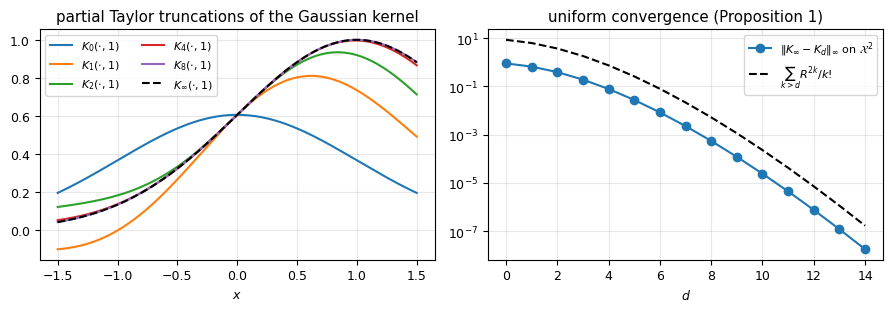

In [4]:
R1 = 1.5                                       # X = [-R1, R1]
omega = lambda x: np.exp(-np.asarray(x, float) ** 2 / 2)

def K_d(x, y, d, R=R1):
    # (1b): omega(x) pi_d(kappa(x,y)) omega(y), kappa = xy/R^2, c_k = R^{2k}/k!
    kap = np.multiply.outer(x, y) / R ** 2
    pi_d = sum(R ** (2 * k) / math.factorial(k) * kap ** k for k in range(d + 1))
    return omega(x)[:, None] * pi_d * omega(y)[None, :]

K_inf = lambda x, y: np.exp(-np.subtract.outer(x, y) ** 2 / 2)

xs = np.linspace(-R1, R1, 301)
A_const = np.exp(R1 ** 2)
rows = []
for d in range(15):
    Kd = K_d(xs, xs, d)
    tail = sum(R1 ** (2 * k) / math.factorial(k) for k in range(d + 1, 80))
    ev = np.linalg.eigvalsh(K_d(xs[::6], xs[::6], d))
    rows.append((d, np.abs(K_inf(xs, xs) - Kd).max(), tail, ev.min() / ev.max(), np.diag(Kd).max()))
print(" d   sup|K_inf-K_d|   tail bound   min/max eig of Gram   sup K_d(x,x)  (A ||omega||^2 = %.2f)" % A_const)
for d, e, t, mn, sd in rows:
    print(f"{d:2d}   {e:12.3e}   {t:10.3e}   {mn:18.1e}   {sd:10.4f}")
assert all(e <= t * (1 + 1e-12) + 1e-15 for _, e, t, _, _ in rows)
assert all(mn > -1e-12 for _, _, _, mn, _ in rows) and all(sd <= A_const for *_, sd in rows)
print("checks of Proposition 1: error <= tail bound, Gram matrices PSD (up to rounding), sup K_d(x,x) <= A: passed")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for i, d in enumerate([0, 1, 2, 4, 8]):
    ax[0].plot(xs, K_d(xs, np.array([1.0]), d)[:, 0], color=f"C{i}", label=f"$K_{{{d}}}(\\cdot,1)$")
ax[0].plot(xs, K_inf(xs, np.array([1.0]))[:, 0], "k--", label="$K_\\infty(\\cdot,1)$")
ax[0].set_xlabel("$x$"); ax[0].legend(ncol=2); ax[0].set_title("partial Taylor truncations of the Gaussian kernel")
ax[1].semilogy([r[0] for r in rows], [r[1] for r in rows], "o-", label="$\\|K_\\infty-K_d\\|_\\infty$ on $\\mathcal{X}^2$")
ax[1].semilogy([r[0] for r in rows], [r[2] for r in rows], "k--", label="$\\sum_{k>d}R^{2k}/k!$")
ax[1].set_xlabel("$d$"); ax[1].legend(); ax[1].set_title("uniform convergence (Proposition 1)")
plt.tight_layout(); plt.show()

Under (A2a) the RKHS of $K_d$ is $\mathcal P_d=\{\omega P:P\in\mathbb R_d[X]\}$ with
$\langle\omega P_1,\omega P_2\rangle_{\mathcal P_d}=\sum_\alpha p_{1,\alpha}p_{2,\alpha}/\lambda_{\alpha,d}$ and
feature map $\Phi^d_t=\omega\sum_\alpha\omega(t)\lambda_{\alpha,d}t^\alpha x^\alpha$ (Section 2.2, Proposition 27).
In dimension one, $\lambda_{k,d}=c_kR^{-2k}=1/k!$. The cell checks the reproducing property
$\langle f,\Phi^d_t\rangle_{\mathcal P_d}=f(t)$ and $\langle\Phi^d_x,\Phi^d_y\rangle_{\mathcal P_d}=K_d(x,y)$, and
prints $\dim\mathcal P_d=\binom{p+d}{d}$.

In [5]:
lam = lambda k: 1 / math.factorial(k)            # lambda_{k,d} for p = 1 (Lemma 26)
def feature_coef(t, d):
    # coefficients of Phi^d_t in the basis (omega x^k)_{k<=d}
    return np.array([omega(t) * lam(k) * t ** k for k in range(d + 1)])
def inner_Pd(p1, p2):
    return sum(a * b / lam(k) for k, (a, b) in enumerate(zip(p1, p2)))

rng = np.random.default_rng(SEED)
d = 6
pc = rng.standard_normal(d + 1)                  # f = omega P
errs = []
for t in rng.uniform(-R1, R1, 5):
    f_t = omega(t) * np.polyval(pc[::-1], t)
    errs.append(abs(inner_Pd(pc, feature_coef(t, d)) - f_t))
x0, y0 = 0.3, -1.1
kerr = abs(inner_Pd(feature_coef(x0, d), feature_coef(y0, d)) - K_d(np.array([x0]), np.array([y0]), d)[0, 0])
print(f"reproducing property, max error over 5 points: {max(errs):.1e};  <Phi_x, Phi_y> - K_d(x,y) = {kerr:.1e}")
print("dim P_d = binom(p+d, d):", {p: [math.comb(p + d, d) for d in (2, 4, 8)] for p in (1, 2, 3)}, "for d = 2, 4, 8")

reproducing property, max error over 5 points: 3.3e-16;  <Phi_x, Phi_y> - K_d(x,y) = 5.6e-17
dim P_d = binom(p+d, d): {1: [3, 5, 9], 2: [6, 15, 45], 3: [10, 35, 165]} for d = 2, 4, 8


Proposition 2: the spaces are nested, $\mathcal P_d\subseteq\mathcal P_{d+1}$, and $\bigcup_d\mathcal P_d=\omega\,\mathbb R[X]$
is dense in $\mathcal C(\mathcal X)$. We compute the least-squares approximation in $\mathcal P_d$ (on 4000
Chebyshev points, in the basis $\omega(x)T_k(x/R)$, which spans the same space as $\omega x^k$) of a continuous
target with a kink, $|x-0.3|$, and of the constant $\mathbf 1$. The discrete $L^2$ error is nonincreasing in $d$
by nesting. The error for $\mathbf 1$ decays much faster but is never zero at finite $d$, since $e^{x^2/2}$ is not a
polynomial; this is the obstruction of Section 4.

$|x-0.3|$    sup error at d = 5, 10, 20, 40: 1.3e-01, 8.1e-02, 4.4e-02, 2.3e-02 | L2 error nonincreasing in d: True
$\mathbf{1}$ sup error at d = 5, 10, 20, 40: 7.8e-03, 1.4e-06, 4.6e-14, 5.0e-15 | L2 error nonincreasing in d: True


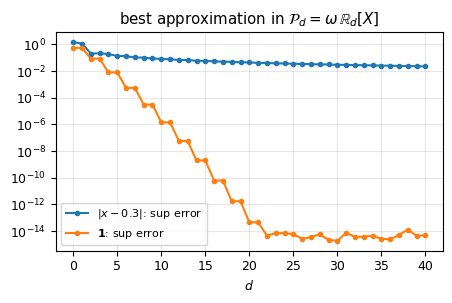

In [6]:
NCH = 4000
xch = R1 * np.cos(np.pi * (np.arange(NCH) + 0.5) / NCH)
targets = {"$|x-0.3|$": np.abs(xch - 0.3), "$\\mathbf{1}$": np.ones(NCH)}
dens = {}
for name, gv in targets.items():
    sup, l2 = [], []
    for d in range(0, 41):
        V = omega(xch)[:, None] * np.polynomial.chebyshev.chebvander(xch / R1, d)
        coef, *_ = np.linalg.lstsq(V, gv, rcond=None)
        r = gv - V @ coef
        sup.append(np.abs(r).max()); l2.append(np.sqrt(np.mean(r ** 2)))
    dens[name] = (np.array(sup), np.array(l2))
    mono = np.all(np.diff(l2) <= 1e-13)
    print(f"{name:12s} sup error at d = 5, 10, 20, 40: " + ", ".join(f"{sup[d]:.1e}" for d in (5, 10, 20, 40))
          + f" | L2 error nonincreasing in d: {mono}")

fig, ax = plt.subplots(figsize=(4.6, 3.1))
for i, (name, (sup, l2)) in enumerate(dens.items()):
    ax.semilogy(range(41), sup, "o-", ms=3, color=f"C{i}", label=f"{name}: sup error")
ax.set_xlabel("$d$"); ax.set_title("best approximation in $\\mathcal{P}_d=\\omega\\,\\mathbb{R}_d[X]$")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Kernel mean embeddings, the moment cone and the sum-of-squares cone (Section 3)

We fix the toy measure $\mu=0.5\,\delta_{-0.8}+0.3\,\delta_{0.1}+0.2\,\delta_{0.9}$ on $\mathcal X=[-1.5,1.5]$.
Its kernel mean embedding (3a) is $\Phi^d\#\mu=\omega\sum_k\lambda_{k,d}\,\mu_k\,x^k$ with the weighted moments
$\mu_k=\int\omega(t)t^k\,\mathrm d\mu(t)$ of (2), which do not depend on $d$; as a function it equals
$x\mapsto\int K_d(x,t)\,\mathrm d\mu(t)$, and it linearises integration, $\langle g,\Phi^d\#\mu\rangle_{\mathcal P_d}=\int g\,\mathrm d\mu$
(3b). As $d\to\infty$ it tends to the Gaussian embedding $\int K_\infty(\cdot,t)\,\mathrm d\mu(t)$.

In [7]:
T_mu = np.array([-0.8, 0.1, 0.9]); A_mu = np.array([0.5, 0.3, 0.2])
wmom = lambda d: np.array([np.sum(A_mu * omega(T_mu) * T_mu ** k) for k in range(d + 1)])   # (2)

def kme(x, d):
    m = wmom(d)
    return omega(x) * sum(lam(k) * m[k] * x ** k for k in range(d + 1))

e_int = max(np.abs(kme(xs, d) - K_d(xs, T_mu, d) @ A_mu).max() for d in range(10))
e_pair = []
for d in range(1, 10):
    pc = rng.standard_normal(d + 1)
    lhs = inner_Pd(pc, [lam(k) * wmom(d)[k] for k in range(d + 1)])       # <g, Phi^d # mu>
    rhs = np.sum(A_mu * omega(T_mu) * np.polyval(pc[::-1], T_mu))         # int g dmu
    e_pair.append(abs(lhs - rhs))
print(f"KME formula vs int K_d(., t) dmu(t): max error {e_int:.1e};  pairing (3b): max error {max(e_pair):.1e}")

KME formula vs int K_d(., t) dmu(t): max error 4.4e-16;  pairing (3b): max error 4.4e-16


The kernel moment cone $\mathbf M_d=\{\Phi^d\#\mu:\mu\in\mathcal M_+(\mathcal X)\}$ of (4a) is, in the coordinates
$(\mu_k)_{k\le d}$, the classical moment cone of the positive measure $\omega\mu$ (the weight is absorbed into the
measure). Its dual is the cone $\mathcal P^+$ of nonnegative elements of $\mathcal P_d$ (Proposition 4), since
$\langle g,\Phi^d_x\rangle=g(x)$. For $d=2$ we plot the normalised slice $(\mu_1/\mu_0,\mu_2/\mu_0)$: the Dirac
embeddings trace the curve $t\mapsto(t,t^2)$, and the slice is its convex hull, which here coincides with the
semidefinite description $M_1\succeq0$, $L(R^2-x^2)\ge0$ (a one-dimensional fact). Random atomic measures and the
toy $\mu$ fall inside.

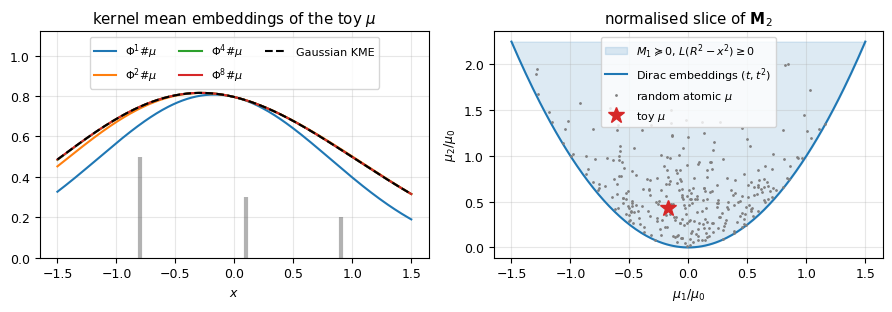

all random measures satisfy M_1 >= 0 and the localizing inequality: True


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for i, d in enumerate([1, 2, 4, 8]):
    ax[0].plot(xs, kme(xs, d), color=f"C{i}", label=f"$\\Phi^{{{d}}}\\#\\mu$")
ax[0].plot(xs, K_inf(xs, T_mu) @ A_mu, "k--", label="Gaussian KME")
ax[0].vlines(T_mu, 0, A_mu, color="0.4", lw=3, alpha=0.5)
ax[0].set_ylim(0, 1.12); ax[0].set_xlabel("$x$"); ax[0].legend(loc="upper center", ncol=3)
ax[0].set_title("kernel mean embeddings of the toy $\\mu$")

tt = np.linspace(-R1, R1, 200)
ax[1].fill_between(tt, tt ** 2, R1 ** 2, color="C0", alpha=0.15, label="$M_1\\succeq0$, $L(R^2-x^2)\\geq0$")
ax[1].plot(tt, tt ** 2, "C0", label="Dirac embeddings $(t,t^2)$")
pts = []
for _ in range(300):                               # random 3-atom measures
    t3 = rng.uniform(-R1, R1, 3); a3 = rng.random(3)
    m = [np.sum(a3 * omega(t3) * t3 ** k) for k in range(3)]
    pts.append((m[1] / m[0], m[2] / m[0]))
pts = np.array(pts)
ax[1].plot(pts[:, 0], pts[:, 1], ".", color="0.5", ms=2, label="random atomic $\\mu$")
m = wmom(2); ax[1].plot(m[1] / m[0], m[2] / m[0], "*", color="C3", ms=12, label="toy $\\mu$")
ax[1].set_xlabel("$\\mu_1/\\mu_0$"); ax[1].set_ylabel("$\\mu_2/\\mu_0$"); ax[1].legend(loc="upper center")
ax[1].set_title("normalised slice of $\\mathbf{M}_2$")
plt.tight_layout(); plt.show()
inside = np.all((pts[:, 1] >= pts[:, 0] ** 2 - 1e-12) & (pts[:, 1] <= R1 ** 2 + 1e-12))
print("all random measures satisfy M_1 >= 0 and the localizing inequality:", bool(inside))

The kernel moment operator (5a), $\mathbf M^{(2)}_d(\mu)=\int\Phi_t\otimes\Phi_t\,\mathrm d\mu(t)$, and the kernel-SoS
cone (5d), $\Sigma_d=\{s_A:A\succeq0\}$ with $s_A(x)=\langle\Phi_x,A\Phi_x\rangle$. In the orthonormal basis
$e_k=\sqrt{\lambda_k}\,\omega x^k$ of $\mathcal P_d$ the operator is $\Lambda^{1/2}M_d(\nu)\Lambda^{1/2}$, with
$\Lambda=\operatorname{diag}(\lambda_k)$ and $M_d(\nu)$ the classical moment matrix of the tilted measure
$\nu=\omega^2\mu$; equivalently, $M_d(\nu)$ is the matrix of the bilinear form $(g,h)\mapsto\langle g,\mathbf M^{(2)}_d(\mu)h\rangle$
in the coefficients of $g=\omega P$, $h=\omega Q$. This is (11a) up to the fixed congruence $\Lambda^{1/2}$, which
changes neither positivity nor rank. The cell checks the pairing (5b),
$\langle A,\mathbf M^{(2)}_d(\mu)\rangle_{\mathrm{HS}}=\int s_A\,\mathrm d\mu$, and Corollary 28,
$s_A=\omega^2\sigma$ with $\sigma$ a sum of squares of degree $2d$. The rank of $\mathbf M^{(2)}_d(\mu)$ is
$\min(d+1,3)$ for the three-atom $\mu$: the moment matrix counts atoms, which is what flat extension uses in Section 5.

In [9]:
def M_tilted(d, T=T_mu, A=A_mu):
    # M_d(nu), nu = omega^2 mu (11a)
    return sum(a * omega(t) ** 2 * np.outer(t ** np.arange(d + 1), t ** np.arange(d + 1)) for a, t in zip(A, T))

for d in (2, 4):
    Lh = np.diag(np.sqrt([lam(k) for k in range(d + 1)]))
    phi = lambda t: np.sqrt([lam(k) for k in range(d + 1)]) * omega(t) * t ** np.arange(d + 1)  # ONB coordinates
    M2 = sum(a * np.outer(phi(t), phi(t)) for a, t in zip(A_mu, T_mu))                        # (5a)
    e1 = np.abs(M2 - Lh @ M_tilted(d) @ Lh).max()
    P, Q = rng.standard_normal(d + 1), rng.standard_normal(d + 1)
    e2 = abs(P @ M_tilted(d) @ Q - np.sum(A_mu * omega(T_mu) ** 2 * np.polyval(P[::-1], T_mu) * np.polyval(Q[::-1], T_mu)))
    G = rng.standard_normal((d + 1, d + 1)); A = G @ G.T                                     # A >= 0
    sA = lambda x: np.array([phi(t) @ A @ phi(t) for t in np.atleast_1d(x)])
    e3 = abs(np.sum(A * M2) - np.sum(A_mu * sA(T_mu)))                                       # (5b)
    S = Lh @ A @ Lh                                                                          # sigma = v^T S v
    sig = np.array([t ** np.arange(d + 1) @ S @ t ** np.arange(d + 1) for t in xs])
    e4 = np.abs(sA(xs) - omega(xs) ** 2 * sig).max()
    print(f"d={d}: |M2 - L^1/2 M_d(nu) L^1/2| = {e1:.1e}, bilinear form {e2:.1e}, pairing (5b) {e3:.1e}, "
          f"s_A - omega^2 sigma {e4:.1e}, min s_A on X = {sA(xs).min():.2e} >= 0")
print("rank of the kernel moment matrix of the 3-atom mu, d = 1..6:",
      [numerical_rank(M_tilted(d), 1e-10)[0] for d in range(1, 7)])

d=2: |M2 - L^1/2 M_d(nu) L^1/2| = 2.8e-17, bilinear form 1.1e-16, pairing (5b) 0.0e+00, s_A - omega^2 sigma 8.9e-16, min s_A on X = 1.04e+00 >= 0
d=4: |M2 - L^1/2 M_d(nu) L^1/2| = 2.8e-17, bilinear form 2.2e-16, pairing (5b) 0.0e+00, s_A - omega^2 sigma 1.3e-15, min s_A on X = 1.24e+00 >= 0
rank of the kernel moment matrix of the 3-atom mu, d = 1..6: [2, 3, 3, 3, 3, 3]


## 3. The constant function and global minimisation (Section 4)

**The obstruction.** $\mathbf 1\in\mathcal P_d$ if and only if $1/\omega\in\mathbb R_d[X]$, which fails for the
Gaussian (Section 4.1). The Taylor series $\mathbf 1=\omega\sum_j x^{2j}/(2^jj!)$ converges uniformly on
$\mathcal X$, but the $\mathcal P_d$-norms of its partial sums, $\sum_{j\le d/2}(2j)!/(4^j(j!)^2)$, grow without
bound (like $\sqrt d$): the Gaussian RKHS $\mathcal P_\infty$ contains no nonzero constant either (Steinwart, Hush
and Scovel, cited in Section 2.2). Augmenting the kernel, $\widetilde K_d=K_d+1$ (7a), puts $\mathbf 1$ in
$\widetilde{\mathcal P}_d=\mathcal P_d+\mathbb R\mathbf 1$ with norm $1$ (Proposition 5). On a Gram matrix with more
points than $\dim\mathcal P_d$, the vector of ones is outside the range for $K_d$ and inside it, with minimal-norm
interpolant of squared norm $1$, for $\widetilde K_d$.

In [10]:
print(" d    P_d-norm^2 of the Taylor partial sum of 1    sup error on X")
for d in (2, 8, 32, 128):
    J = d // 2
    nrm2 = sum(math.comb(2 * j, j) / 4 ** j for j in range(J + 1))       # (2j)!/(4^j (j!)^2)
    approx = omega(xs) * sum(xs ** (2 * j) / (2 ** j * math.factorial(j)) for j in range(J + 1))
    print(f"{d:4d}   {nrm2:10.3f}   (2 sqrt(J/pi) = {2 * math.sqrt(J / math.pi):6.3f})            {np.abs(1 - approx).max():.1e}")

pts = np.linspace(-R1, R1, 40)
for d in (2, 4, 6):
    G = K_d(pts, pts, d); one = np.ones(len(pts))
    Gp = np.linalg.pinv(G, rcond=1e-13)
    res = np.linalg.norm(one - G @ Gp @ one) / np.linalg.norm(one)
    Gt = G + 1.0
    Gtp = np.linalg.pinv(Gt, rcond=1e-13)
    res_t = np.linalg.norm(one - Gt @ Gtp @ one) / np.linalg.norm(one)
    print(f"d={d}: 40 points, rank K_d = {np.linalg.matrix_rank(G, 1e-13 * np.abs(G).max())}; "
          f"1 outside range(K_d): relative residual {res:.1e};  K_d+1: residual {res_t:.1e}, "
          f"squared norm of the interpolant {one @ Gtp @ one:.6f}")

 d    P_d-norm^2 of the Taylor partial sum of 1    sup error on X
   2        1.500   (2 sqrt(J/pi) =  1.128)            3.1e-01
   8        2.461   (2 sqrt(J/pi) =  2.257)            6.0e-03
  32        4.618   (2 sqrt(J/pi) =  4.514)            7.1e-15
 128        9.080   (2 sqrt(J/pi) =  9.027)            4.4e-16
d=2: 40 points, rank K_d = 3; 1 outside range(K_d): relative residual 4.8e-02;  K_d+1: residual 1.3e-14, squared norm of the interpolant 1.000000
d=4: 40 points, rank K_d = 5; 1 outside range(K_d): relative residual 4.9e-03;  K_d+1: residual 4.8e-13, squared norm of the interpolant 1.000000
d=6: 40 points, rank K_d = 7; 1 outside range(K_d): relative residual 3.6e-04;  K_d+1: residual 1.5e-10, squared norm of the interpolant 1.000000


The augmented cone (8) contains the constants, but the certificate $f-\lambda\mathbf 1\in\widetilde\Sigma_d$ is
useless for $f=\omega^2q$: since $1,\omega,\omega^2$ are linearly independent over the polynomials, matching the
three blocks forces $\sigma=q$, $b=0$ and $c=-\lambda\ge0$, so the best certified bound is $\lambda=0$ whatever
$f^\star$ is (Section 4.2). The SDP below poses exactly this coefficient matching for $q(x)=x^4-2x^2+0.5x+2$
($q>0$, so $f^\star>0$).

In [11]:
q_plus = {(4,): 1.0, (2,): -2.0, (1,): 0.5, (0,): 2.0}
fq = lambda q, x: omega(x) ** 2 * peval(q, np.asarray(x, float).reshape(-1, 1))
dA = 2
B = cp.Variable((dA + 1, dA + 1), symmetric=True); b = cp.Variable(dA + 1); c = cp.Variable(); lmb = cp.Variable()
Afull = cp.bmat([[B, cp.reshape(b, (dA + 1, 1), order="C")], [cp.reshape(b, (1, dA + 1), order="C"), cp.reshape(c, (1, 1), order="C")]])
cons = [Afull >> 0, b == 0, c == -lmb]                           # omega-block and constant block
cons += [sum(B[i, k - i] for i in range(max(0, k - dA), min(k, dA) + 1)) == q_plus.get((k,), 0.0) for k in range(2 * dA + 1)]
prob = cp.Problem(cp.Maximize(lmb), cons)
val = solve(prob, "s3 augmented certificate")
xfine = np.linspace(-R1, R1, 30001)
print(f"sup{{lambda : f - lambda 1 in augmented SoS cone}} = {val:.2e}  ({SOLVER_LOG[-1][1]} {SOLVER_LOG[-1][2]}),"
      f"  while f* = {fq(q_plus, xfine).min():.4f}")

sup{lambda : f - lambda 1 in augmented SoS cone} = 1.57e-09  (CLARABEL optimal),  while f* = 0.1401


**The datum $\theta_d$.** Under (W), $\omega^{-2}=g(|x|^2)$ with $g=\exp$ for the Gaussian, and
$\theta_d=\sum_{k\le d}|x|^{2k}/k!$ is its partial Taylor truncation of degree $2d$. Then $\theta_d\ge1$,
$\omega^2\theta_d\to\mathbf 1$ uniformly (10a), and Lemma 12 gives $\varepsilon_d=\|\omega^{-2}-\theta_d\|_\infty\le e^{R^2}R^{2(d+1)}/(d+1)!$.

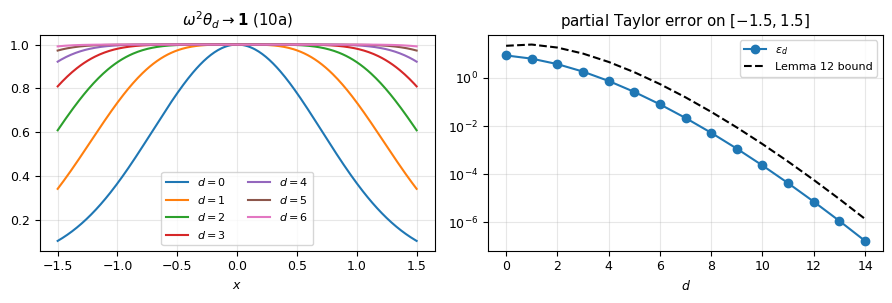

eps_d <= bound for all d: True | min theta_d >= 1: True


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.1))
eps_rows = []
for d in range(0, 15):
    th = theta(1, d); thv = peval(th, xs[:, None])
    eps_rows.append((d, np.max(np.exp(xs ** 2) - thv), np.exp(R1 ** 2) * R1 ** (2 * (d + 1)) / math.factorial(d + 1), thv.min()))
    if d <= 6:
        ax[0].plot(xs, omega(xs) ** 2 * thv, color=f"C{d}", label=f"$d={d}$")
ax[0].set_xlabel("$x$"); ax[0].set_title("$\\omega^2\\theta_d\\to\\mathbf{1}$ (10a)"); ax[0].legend(ncol=2)
ax[1].semilogy([r[0] for r in eps_rows], [r[1] for r in eps_rows], "o-", label="$\\varepsilon_d$")
ax[1].semilogy([r[0] for r in eps_rows], [r[2] for r in eps_rows], "k--", label="Lemma 12 bound")
ax[1].set_xlabel("$d$"); ax[1].legend(); ax[1].set_title("partial Taylor error on $[-1.5,1.5]$")
plt.tight_layout(); plt.show()
print("eps_d <= bound for all d:", all(e <= bnd for _, e, bnd, _ in eps_rows), "| min theta_d >= 1:", all(m >= 1 for *_, m in eps_rows))

**The relaxation (10b)–(10c).** On $\mathcal X=[-1.5,1.5]=\{R^2-x^2\ge0\}$ (the ball constraint is the only $g_j$) we
solve $\rho_d=\inf\{L_y(q):L_y(\theta_d)=1,\ M_d(y)\succeq0,\ M_{d-1}((R^2-x^2)y)\succeq0\}$ for $f=\omega^2q$ with
$q_-=x^4-2x^2+0.5x$ ($f^\star<0$) and $q_+=q_-+2$ ($f^\star>0$). The dual value $\lambda_d$ is read from the
multiplier of $L_y(\theta_d)=1$. The table checks Proposition 6 ($\lambda_d=\rho_d$), Theorem 8 ($\rho_d\to f^\star$),
Proposition 7 (the validated bound is below $f^\star$), and the surrogate $f^\star_d=\min q/\theta_d$ of (14b):
in one variable the quadratic module of an interval contains every nonnegative polynomial of the right degree
(Lukács), so $\rho_d=f^\star_d$ already at order $d$. For $f^\star<0$, $\rho_d\le f^\star$; for $f^\star>0$, $\rho_d$ lies above
$f^\star$, which is why the paper says $\lambda_d$ need not lower-bound $f^\star$ and introduces the validated bound. These
inequalities hold up to the accuracy of the solver, about $10^{-7}$ here (several solves end as `optimal_inaccurate`):
a bound computed in floating point is validated only after a separate verification of the certificate.

--- q_-: f* = -0.674441129 at x* = -0.75471, ||q||_inf = 1.515
 d    rho_d          lambda_d       validated bound   f*_d (surrogate)   rho_d - f*   rho_d - f*_d   ||q|| eps_d
 2  -0.689529553  -0.689529553  -0.689529553      -0.689529573     -1.51e-02    +2.0e-08      5.6e+00
 3  -0.676366557  -0.676366557  -0.676366557      -0.676366559     -1.93e-03    +1.7e-09      2.7e+00
 4  -0.674652205  -0.674652206  -0.674652206      -0.674652213     -2.11e-04    +8.2e-09      1.1e+00
 5  -0.674460817  -0.674460818  -0.674460818      -0.674460819     -1.97e-05    +2.3e-09      3.9e-01
 6  -0.674442684  -0.674442688  -0.674442688      -0.674442714     -1.55e-06    +3.0e-08      1.2e-01
 7  -0.674441225  -0.674441227  -0.674441227      -0.674441241     -9.51e-08    +1.7e-08      3.3e-02
 8  -0.674441056  -0.674441068  -0.674441068      -0.674441136     +7.37e-08    +8.1e-08      7.9e-03
 9  -0.674441111  -0.674441115  -0.674441115      -0.674441130     +1.81e-08    +1.9e-08      1.7e-03
max (val

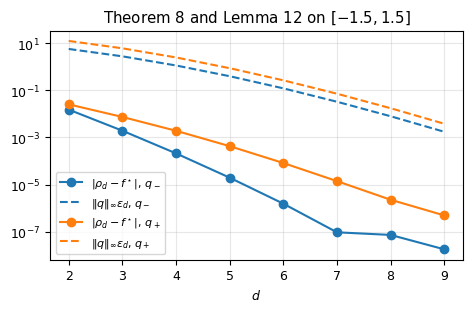

In [13]:
q_minus = {(4,): 1.0, (2,): -2.0, (1,): 0.5}
ball1 = {(0,): R1 ** 2, (2,): -1.0}

def fstar_1d(fun, lo, hi, n=30001):
    # grid search, then bounded scalar refinement around the best grid point
    x = np.linspace(lo, hi, n); v = np.asarray(fun(x)).ravel(); i = int(np.argmin(v))
    f1 = lambda z: float(np.asarray(fun(np.array([z]))).ravel()[0])
    r = minimize_scalar(f1, bounds=(x[max(i - 1, 0)], x[min(i + 1, n - 1)]), method="bounded", options={"xatol": 1e-12})
    return (float(r.fun), float(r.x)) if r.fun < v[i] else (float(v[i]), float(x[i]))

def relax_1d(q, d, gs, label):
    mom = Moments(1, d); th = theta(1, d)
    cons = [mom.M(d) >> 0] + [mom.M(d - 1, g) >> 0 for g in gs] + [mom.L(th) == 1]
    prob = cp.Problem(cp.Minimize(mom.L(q)), cons)
    val = solve(prob, label)
    return val, (-cons[-1].dual_value if val is not None else None), mom

res3 = {}
for name, q in (("q_-", q_minus), ("q_+", q_plus)):
    fs, xstar = fstar_1d(lambda x: fq(q, x), -R1, R1)
    qsup = pnorm_sup(q, xs[:, None])
    print(f"--- {name}: f* = {fs:.9f} at x* = {xstar:.5f}, ||q||_inf = {qsup:.3f}")
    print(" d    rho_d          lambda_d       validated bound   f*_d (surrogate)   rho_d - f*   rho_d - f*_d   ||q|| eps_d")
    rows = []
    for d in range(2, 10):
        val, lam_d, mom = relax_1d(q, d, [ball1], f"s3 {name} d={d}")
        th = theta(1, d)
        w2th = omega(xfine) ** 2 * peval(th, xfine[:, None])
        valid = lam_d * w2th.min() if lam_d >= 0 else lam_d * w2th.max()                    # Proposition 7
        fsd, _ = fstar_1d(lambda x: peval(q, np.reshape(x, (-1, 1))) / peval(th, np.reshape(x, (-1, 1))), -R1, R1)
        epsd = np.exp(R1 ** 2) - peval(th, np.array([[R1]]))[0]
        rows.append((d, val, lam_d, valid, fsd, epsd))
        print(f"{d:2d}  {val:+.9f}  {lam_d:+.9f}  {valid:+.9f}      {fsd:+.9f}     {val - fs:+.2e}    {val - fsd:+.1e}      {qsup * epsd:.1e}")
    res3[name] = (fs, rows, qsup)
    print(f"max (validated bound - f*) = {max(r[3] - fs for r in rows):+.1e} (<= 0 up to the solver accuracy)",
          f"| max |rho_d - lambda_d| = {max(abs(r[1] - r[2]) for r in rows):.1e}",
          f"| max |rho_d - f*_d| = {max(abs(r[1] - r[4]) for r in rows):.1e}")
print("solver statuses:", status_summary("s3"))

fig, ax = plt.subplots(figsize=(4.8, 3.2))
for i, (name, (fs, rows, qsup)) in enumerate(res3.items()):
    ax.semilogy([r[0] for r in rows], [abs(r[1] - fs) for r in rows], "o-", color=f"C{i}", label=f"$|\\rho_d-f^\\star|$, ${name}$")
    ax.semilogy([r[0] for r in rows], [qsup * r[5] for r in rows], "--", color=f"C{i}", label=f"$\\|q\\|_\\infty\\varepsilon_d$, ${name}$")
ax.set_xlabel("$d$"); ax.legend(); ax.set_title("Theorem 8 and Lemma 12 on $[-1.5,1.5]$")
plt.tight_layout(); plt.show()

**Dropping the ball constraint (Remark 3).** On $\mathcal X=[0,1]=\{x\ge0,\,1-x\ge0\}$ with $q=1+x$
($f^\star=2/e$), the sequence $y=(0,\dots,0,1/a_d)$ is feasible with value $0$, because $y_{2d}$ enters only $M_d(y)$.
Adding the redundant constraint $1-x^2\ge0$ restores $\rho_d\to2/e$.

In [14]:
q_ball = {(0,): 1.0, (1,): 1.0}
g01 = [{(1,): 1.0}, {(0,): 1.0, (1,): -1.0}]
print(" d   rho_d without 1-x^2   rho_d with 1-x^2   (2/e = %.6f)   y=(0,..,0,d!) feasible, value" % (2 / np.e))
for d in range(1, 7):
    v0, _, m0 = relax_1d(q_ball, d, g01, f"s3 rem3 d={d} no ball")
    v1, _, _ = relax_1d(q_ball, d, g01 + [{(0,): 1.0, (2,): -1.0}], f"s3 rem3 d={d} ball")
    y = np.zeros(2 * d + 1); y[-1] = math.factorial(d)                      # 1/a_d with a_d = 1/d!
    feas = (np.linalg.eigvalsh(m0.M(d, y=y)).min() >= 0 and all(np.linalg.eigvalsh(m0.M(d - 1, g, y=y)).min() >= 0 for g in g01)
            and abs(m0.L(theta(1, d), y) - 1) < 1e-12)
    print(f"{d:2d}   {v0:+.2e}              {v1:.6f}                             {feas}, {m0.L(q_ball, y):.1f}")
print("solver statuses:", status_summary("s3 rem3"))

 d   rho_d without 1-x^2   rho_d with 1-x^2   (2/e = 0.735759)   y=(0,..,0,d!) feasible, value
 1   -2.56e-10              0.500000                             True, 0.0
 2   -5.36e-10              0.800000                             True, 0.0
 3   +1.77e-09              0.750000                             True, 0.0
 4   +5.53e-10              0.738462                             True, 0.0
 5   +3.13e-07              0.736196                             True, 0.0
 6   +4.96e-06              0.735820                             True, 0.0
solver statuses: 10 x CLARABEL optimal, 2 x CLARABEL optimal_inaccurate


**Non-compact carriers (Proposition 9).** On $\mathcal X=\mathbb R$ there is no localizing constraint; the
normalisation $L_y(\theta_d)=1$ bounds each $a_kL_y(x^{2k})$ by $1$, and convergence needs the tightness
condition (T). We print the tail $\sum_{k=r+1}^d a_kL_{y^{(d)}}(x^{2k})$ at $r=d-2$. For $q_-$ ($f^\star$ attained)
the tail vanishes and $\rho_d\to f^\star$. For $q_+$ on $\mathbb R$, $f=\omega^2q_+>0$ tends to $0$ at infinity, so
$\inf f=0$ is not attained (the proposition assumes attainment): the optimum puts the whole normalisation on the
top moment, $a_dy_{2d}\approx1$, which is mass escaping to infinity, and (T) fails. We stop at $d=8$, beyond
which the solver loses accuracy on these badly scaled instances.

In [15]:
for name, q in (("q_-", q_minus), ("q_+", q_plus)):
    fs, _ = fstar_1d(lambda x: fq(q, x), -8, 8, 160001)
    print(f"--- {name} on R: inf f = {fs:.7f}")
    for d in range(2, 9):
        val, _, mom = relax_1d(q, d, [], f"s3 R {name} d={d}")
        y = mom.y.value
        tail = sum(y[2 * k] / math.factorial(k) for k in range(d - 1, d + 1))
        print(f"  d={d}: rho_d = {val:+.7f}  (rho_d - inf f = {val - fs:+.1e}),  tail at r=d-2: {tail:.2e},  a_d y_2d = {y[2 * d] / math.factorial(d):.2e}")
print("solver statuses:", status_summary("s3 R"))

--- q_- on R: inf f = -0.6744411
  d=2: rho_d = -0.6895296  (rho_d - inf f = -1.5e-02),  tail at r=d-2: 4.42e-01,  a_d y_2d = 1.03e-01
  d=3: rho_d = -0.6763666  (rho_d - inf f = -1.9e-03),  tail at r=d-2: 1.11e-01,  a_d y_2d = 1.79e-02
  d=4: rho_d = -0.6746522  (rho_d - inf f = -2.1e-04),  tail at r=d-2: 2.00e-02,  a_d y_2d = 2.49e-03
  d=5: rho_d = -0.6744608  (rho_d - inf f = -2.0e-05),  tail at r=d-2: 2.77e-03,  a_d y_2d = 2.83e-04
  d=6: rho_d = -0.6744427  (rho_d - inf f = -1.6e-06),  tail at r=d-2: 3.10e-04,  a_d y_2d = 2.68e-05
  d=7: rho_d = -0.6744412  (rho_d - inf f = -1.1e-07),  tail at r=d-2: 2.90e-05,  a_d y_2d = 2.19e-06
  d=8: rho_d = -0.6744411  (rho_d - inf f = -2.4e-10),  tail at r=d-2: 2.35e-06,  a_d y_2d = 1.63e-07
--- q_+ on R: inf f = 0.0000000
  d=2: rho_d = +0.1653139  (rho_d - inf f = +1.7e-01),  tail at r=d-2: 6.82e-01,  a_d y_2d = 2.69e-01
  d=3: rho_d = +0.0000000  (rho_d - inf f = +3.4e-09),  tail at r=d-2: 1.00e+00,  a_d y_2d = 1.00e+00
  d=4: rho_d = +0

## 4. Finite representation, flat extension and the Christoffel strengthening (Section 5)

On the finite-dimensional levels the kernel moment matrix is the moment matrix of the tilted measure
$\nu=\omega^2\mu$ (11a), and (10b) is the SDP (11b). Theorem 10: if $\operatorname{rank}M_{d-d_0}(y^\star)=\operatorname{rank}M_d(y^\star)$
(12), then $y^\star$ is the moment sequence of an atomic $\nu^\star=\sum_ia_i\delta_{x_i}$, extracted by linear algebra, with
atoms in the contact set $\{q=\lambda_d\theta_d\}$. We take $\mathcal X$ the unit disk $\{1-|x|^2\ge0\}$ (so $d_0=1$),
$\omega=e^{-|x|^2/2}$ and $q(x)=(x_1^2-0.36)^2+x_2^2-0.05$, whose $f=\omega^2q$ has two global minimisers $(\pm x^\star_1,0)$.
The extracted atoms are the minimisers of the surrogate $f^\star_d=\min q/\theta_d$ (14b), and they approach those of $f$ as
$\varepsilon_d\to0$; the normalisation reads $\sum_ia_i\theta_d(x_i)=1$.

f* = -0.0353198862, minimisers of f: [[-0.579055, 0.0], [0.579055, 0.0]]
 d   rho_d            f*_d             rho_d-f*_d  rho_d-f*    ranks M_{d-1},M_d  sum a_i theta_d(x_i)  dist to argmin f*_d / argmin f


 2  -0.0354943835  -0.0354943829  -5.8e-10   -1.7e-04      2, 2              1.00000000           7.8e-06 / 8.4e-04


 3  -0.0353341476  -0.0353341479  +3.1e-10   -1.4e-05      2, 2              1.00000000           1.7e-05 / 7.7e-05


 4  -0.0353208381  -0.0353208307  -7.4e-09   -9.5e-07      2, 2              1.00000001           3.2e-05 / 4.0e-05


 5  -0.0353199452  -0.0353199385  -6.7e-09   -5.9e-08      2, 2              1.00000001           2.4e-05 / 2.4e-05


 6  -0.0353198977  -0.0353198887  -9.0e-09   -1.2e-08      2, 2              1.00000001           2.9e-06 / 2.8e-06
solver statuses: 2 x CLARABEL optimal, 3 x CLARABEL optimal_inaccurate


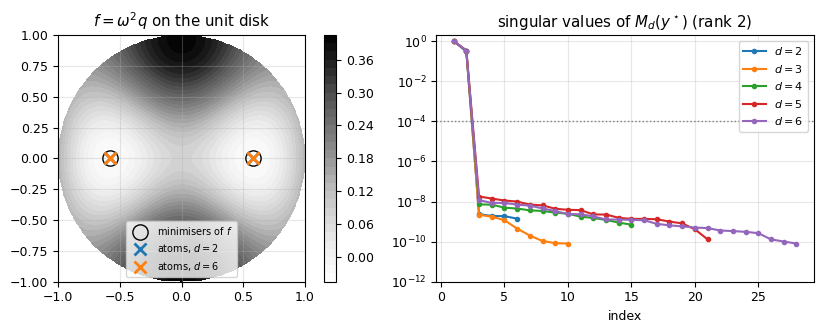

In [16]:
q2 = {(4, 0): 1.0, (2, 0): -0.72, (0, 0): 0.36 ** 2 - 0.05, (0, 2): 1.0}
disk = {(0, 0): 1.0, (2, 0): -1.0, (0, 2): -1.0}
f2 = lambda x: np.exp(-np.sum(np.atleast_2d(x) ** 2, 1)) * peval(q2, x)

def argmin_2d(fun, n=401):
    # grid search on the disk, then local refinement of the two best grid points of the two half-disks
    t = np.linspace(-1, 1, n); X, Y = np.meshgrid(t, t); P = np.column_stack([X.ravel(), Y.ravel()])
    P = P[np.sum(P ** 2, 1) <= 1]; v = fun(P); out = []
    for side in (P[:, 0] < 0, P[:, 0] >= 0):
        x0 = P[side][np.argmin(v[side])]
        r = minimize(lambda z: fun(z[None, :])[0], x0, method="Nelder-Mead", options={"xatol": 1e-11, "fatol": 1e-15})
        out.append((r.fun, r.x))
    return min(o[0] for o in out), np.array([o[1] for o in out])

fs2, xmin2 = argmin_2d(f2)
tq = np.linspace(-1, 1, 401); PQ = np.column_stack([a.ravel() for a in np.meshgrid(tq, tq)]); PQ = PQ[np.sum(PQ ** 2, 1) <= 1]
qsup2 = np.abs(peval(q2, PQ)).max()                                     # ||q||_inf on the disk (grid)
print(f"f* = {fs2:.10f}, minimisers of f: {np.round(xmin2, 6).tolist()}")
res4 = []
print(" d   rho_d            f*_d             rho_d-f*_d  rho_d-f*    ranks M_{d-1},M_d  sum a_i theta_d(x_i)  dist to argmin f*_d / argmin f")
for d in range(2, 7):
    mom = Moments(2, d); th = theta(2, d)
    cons = [mom.M(d) >> 0, mom.M(d - 1, disk) >> 0, mom.L(th) == 1]
    val = solve(cp.Problem(cp.Minimize(mom.L(q2)), cons), f"s4 d={d}")
    y = mom.y.value
    at, w, r, r0 = extract_atoms(y, mom, d, 1e-4)
    fsd, xsd = argmin_2d(lambda x: peval(q2, x) / peval(th, x))
    dist_s = max(min(np.linalg.norm(a - z) for z in xsd) for a in at)
    dist_f = max(min(np.linalg.norm(a - z) for z in xmin2) for a in at)
    _, sv = numerical_rank(mom.M(d, y=y), 1e-4)
    res4.append(dict(d=d, val=val, fsd=fsd, atoms=at, w=w, sv=sv, eps=np.e - peval(th, np.array([[1.0, 0]]))[0]))
    print(f"{d:2d}  {val:+.10f}  {fsd:+.10f}  {val - fsd:+.1e}   {val - fs2:+.1e}      {r0}, {r}              "
          f"{np.sum(w * peval(th, at)):.8f}           {dist_s:.1e} / {dist_f:.1e}")
print("solver statuses:", status_summary("s4"))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
t = np.linspace(-1, 1, 301); X, Y = np.meshgrid(t, t); P = np.column_stack([X.ravel(), Y.ravel()])
F = f2(P).reshape(X.shape); F[X ** 2 + Y ** 2 > 1] = np.nan
cs = ax[0].contourf(X, Y, F, levels=30, cmap="Greys"); fig.colorbar(cs, ax=ax[0], fraction=0.046)
ax[0].plot(xmin2[:, 0], xmin2[:, 1], "o", mfc="none", mec="k", ms=11, label="minimisers of $f$")
for i, k in enumerate([0, 4]):
    ax[0].plot(res4[k]["atoms"][:, 0], res4[k]["atoms"][:, 1], "x", color=f"C{i}", ms=9, mew=2, label=f"atoms, $d={res4[k]['d']}$")
ax[0].set_aspect("equal"); ax[0].legend(loc="lower center", fontsize=7); ax[0].set_title("$f=\\omega^2q$ on the unit disk")
for i, r in enumerate(res4):
    ax[1].semilogy(range(1, len(r["sv"]) + 1), np.maximum(r["sv"], 1e-12), "o-", ms=3, color=f"C{i}", label=f"$d={r['d']}$")
ax[1].axhline(1e-4, color="0.5", ls=":", lw=1); ax[1].set_ylim(1e-12, 2)
ax[1].set_xlabel("index"); ax[1].set_title("singular values of $M_d(y^\\star)$ (rank 2)"); ax[1].legend()
plt.tight_layout(); plt.show()

**Truncation order versus relaxation order (Theorem 13).** Fix the truncation $d$ of $\theta_d$ and raise the
relaxation order $n\ge d$ in (14a). Under the optimality conditions the values $\rho_{d,n}$ equal $f^\star_d$ from a
finite $n^\star$ on, with a flat truncation. In this example $n^\star=d$ already. Lemma 12 and
Theorem 13 then give $|f^\star_d-f^\star|\le\|q\|_\infty\varepsilon_d$, with $\varepsilon_d=e-\theta_d(1)$ on the unit disk.

In [17]:
for d in (2, 3):
    th = theta(2, d)
    fsd = [r["fsd"] for r in res4 if r["d"] == d][0]
    for n in range(d, d + 3):
        mom = Moments(2, n)
        val = solve(cp.Problem(cp.Minimize(mom.L(q2)), [mom.M(n) >> 0, mom.M(n - 1, disk) >> 0, mom.L(th) == 1]), f"s4 dn d={d} n={n}")
        ranks = [numerical_rank(mom.M(k, y=mom.y.value), 1e-4)[0] for k in range(1, n + 1)]
        print(f"d={d}, n={n}: rho_dn - f*_d = {val - fsd:+.1e}, ranks of M_1..M_n = {ranks}")
print(" d   |f*_d - f*|   ||q|| eps_d")
for r in res4:
    print(f"{r['d']:2d}   {abs(r['fsd'] - fs2):.2e}      {qsup2 * r['eps']:.2e}")
print("solver statuses:", status_summary("s4 dn"))

d=2, n=2: rho_dn - f*_d = -5.8e-10, ranks of M_1..M_n = [2, 2]
d=2, n=3: rho_dn - f*_d = -3.3e-09, ranks of M_1..M_n = [2, 2, 2]
d=2, n=4: rho_dn - f*_d = -5.2e-09, ranks of M_1..M_n = [2, 2, 2, 2]
d=3, n=3: rho_dn - f*_d = +3.1e-10, ranks of M_1..M_n = [2, 2, 2]
d=3, n=4: rho_dn - f*_d = -7.1e-09, ranks of M_1..M_n = [2, 2, 2, 2]
d=3, n=5: rho_dn - f*_d = -7.3e-09, ranks of M_1..M_n = [2, 2, 2, 2, 2]
 d   |f*_d - f*|   ||q|| eps_d
 2   1.74e-04      2.36e-01
 3   1.43e-05      5.57e-02
 4   9.45e-07      1.07e-02
 5   5.23e-08      1.74e-03
 6   2.49e-09      2.44e-04
solver statuses: 3 x CLARABEL optimal, 3 x CLARABEL optimal_inaccurate


**The kernel Christoffel polynomial (Section 5.3).** For an optimum $y^\star$ with $M_d(y^\star)=\sum_ie_ip_ip_i^\top$,
$\widetilde\Lambda^{y^\star}_d=v_d^\top(M_d(y^\star)+\rho_CI)^{-1}v_d$ (13a) is small on the support of a representing measure
and large off it, and $L_{y^\star}(\widetilde\Lambda^{y^\star}_d)=\sum_ie_i/(e_i+\rho_C)$ tends to the rank as $\rho_C\to0$
(Proposition 11 (i)). We use $q=|x-p_1|^2|x-p_2|^2$ with $p_1=(-0.5,0.2)$, $p_2=(0.4,-0.3)$ on the unit disk at
$d=2$, $n=3$: $f^\star=f^\star_d=0$ with the two minimisers $p_1,p_2$, and the base optimum is flat of rank $2$.
For a normalised Dirac $\delta_x/\theta_d(x)$ the constraint of (13b) reads $\ell(x):=\widetilde\Lambda^{y^\star}_d(x)/\theta_d(x)\le\gamma$,
and at the optimum $L_{y^\star}(\widetilde\Lambda)=\sum_jc_j\ell(p_j)$ with $c_j=a_j\theta_d(p_j)$, $\sum_jc_j=1$.

In [18]:
p1, p2 = np.array([-0.5, 0.2]), np.array([0.4, -0.3])
dist2 = lambda p: {(2, 0): 1.0, (0, 2): 1.0, (1, 0): -2 * p[0], (0, 1): -2 * p[1], (0, 0): float(p @ p)}
qc = pmul(dist2(p1), dist2(p2))
dC, nC, RHO_C = 2, 3, 1e-3
thC = theta(2, dC); basisC = monomials(2, nC)

def christoffel_sdp(extra, label):
    mom = Moments(2, nC)
    cons = [mom.M(nC) >> 0, mom.M(nC - 1, disk) >> 0, mom.L(thC) == 1] + extra(mom)
    val = solve(cp.Problem(cp.Minimize(mom.L(qc)), cons), label)
    return val, mom

val0, momC = christoffel_sdp(lambda m: [], "s4c base")
y0 = momC.y.value; M0 = momC.M(nC, y=y0)
at0, w0, r0, _ = extract_atoms(y0, momC, nC)
print(f"base: value {val0:.1e}, rank {r0}, atoms {np.round(at0, 4).tolist()}, c_j = {np.round(w0 * peval(thC, at0), 4)}")
print("Proposition 11 (i): L_y*(Lambda) for rho_C = 1e-1 ... 1e-5:",
      [round(float(np.sum(np.linalg.inv(M0 + rc * np.eye(len(M0))) * M0)), 4) for rc in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5)])
W0 = np.linalg.inv(M0 + RHO_C * np.eye(len(M0))); Lam0 = gram_poly(W0, basisC); L0 = float(np.sum(W0 * M0))
ell = lambda x: peval(Lam0, x) / peval(thC, x)
print(f"rho_C = {RHO_C}: L_y*(Lambda) = {L0:.5f};  ell(p_1) = {ell(p1[None])[0]:.5f}, ell(p_2) = {ell(p2[None])[0]:.5f}")

base: value -6.3e-09, rank 2, atoms [[0.4001, -0.3], [-0.5001, 0.2001]], c_j = [0.5043 0.4957]
Proposition 11 (i): L_y*(Lambda) for rho_C = 1e-1 ... 1e-5: [1.5725, 1.9433, 1.9941, 1.9994, 2.0002]
rho_C = 0.001: L_y*(Lambda) = 1.99413;  ell(p_1) = 2.01115, ell(p_2) = 1.97690


**H1 (13b).** With $\gamma=(1-\varepsilon)L_{y^\star}(\widetilde\Lambda)$ the constraint removes $y^\star$ (Proposition 11 (ii)). Here
$\min_j\ell(p_j)$ is only about $1\%$ below $L_{y^\star}(\widetilde\Lambda)$, because the two atoms carry almost equal
weights $c_j$. With $\varepsilon=0.2$ (the value used in Section 6.5) no normalised Dirac at a minimiser satisfies the
constraint, and the strengthened program is infeasible: $\widetilde\rho_d(\gamma)=+\infty$, so (ii) holds trivially
and the premise of (iii) fails. With $\varepsilon=0.01$ the premise fails narrowly at the first step
($\gamma<\ell(p_2)$, and the value rises slightly above $f^\star_d=0$); from the second step on it holds, and the
iterations move the mass to $p_2$ at the value $f^\star_d$ up to the solver accuracy (Proposition 11 (iii)). On a flat
optimum H1 can only select among the atoms, and only when their weights differ.

**H2.** The marginal variant takes a local solution $\bar x$ and adds, for each coordinate $i$, the localizing
constraint $M_{n-d_m}((\gamma_i-\widetilde\Lambda^{y^\star_{[i]}}_{d_m})y)\succeq0$ with $\gamma_i=\widetilde\Lambda^{y^\star_{[i]}}_{d_m}(\bar x_i)$
($d_m=2$, $\rho_C=10^{-2}$). The normalised Dirac at $\bar x$ is feasible by construction, so the value cannot exceed
$f^\star_d$ when $\bar x$ is a surrogate minimiser. With $\bar x=p_2$ the other atom has larger marginal Christoffel
values and is cut off (rank 1); with $\bar x=p_1$ both atoms stay.

--- H1, eps = 0.2


  it 0: gamma = 1.5953: no solution (CLARABEL SolverError, SCS infeasible)
--- H1, eps = 0.01
  it 0: gamma = 1.9742, ell(p_2) = 1.9769, value +1.2e-06, sv_2/sv_1 = 3.9e-03, atoms [[0.399, -0.299], [-0.496, 0.198]] with c_j [0.9941 0.0059]  [CLARABEL optimal_inaccurate]
  it 1: gamma = 1.7794, ell(p_2) = 1.0077, value +1.2e-08, sv_2/sv_1 = 3.0e-03, atoms [[0.4, -0.3], [-0.499, 0.201]] with c_j [0.9955 0.0045]  [CLARABEL optimal_inaccurate]
  it 2: gamma = 1.7347, ell(p_2) = 1.0031, value +1.8e-07, sv_2/sv_1 = 2.2e-03, atoms [[0.4, -0.3], [-0.499, 0.202]] with c_j [0.9967 0.0033]  [CLARABEL optimal_inaccurate]
  it 3: gamma = 1.6776, ell(p_2) = 1.0020, value +1.3e-07, sv_2/sv_1 = 1.6e-03, atoms [[0.4, -0.3], [-0.5, 0.201]] with c_j [0.9976 0.0024]  [CLARABEL optimal_inaccurate]
  it 4: gamma = 1.6053, ell(p_2) = 1.0011, value +1.4e-07, sv_2/sv_1 = 1.2e-03, atoms [[0.398, -0.299]] with c_j [0.9982]  [CLARABEL optimal_inaccurate]
  it 5: gamma = 1.5351, ell(p_2) = 1.0005, value +7.4e-08, 

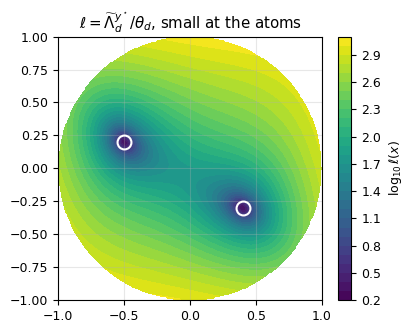

In [19]:
def h1(eps, iters, label):
    y = y0.copy(); hist = []
    for it in range(iters):
        M = momC.M(nC, y=y); W = np.linalg.inv(M + RHO_C * np.eye(len(M)))
        gam = (1 - eps) * float(np.sum(W * M)); Lp = gram_poly(W, basisC)
        val, mom = christoffel_sdp(lambda m: [m.L(Lp) <= gam], f"{label} it={it}")
        st = SOLVER_LOG[-1]
        if val is None:
            hist.append((it, None, gam, None, None, f"{SOLVER_LOG[-2][1]} {SOLVER_LOG[-2][2]}, {st[1]} {st[2]}", None)); break
        prem = float(peval(Lp, p2[None])[0] / peval(thC, p2[None])[0])          # ell(p_2) for the current Lambda
        y = mom.y.value; _, sv = numerical_rank(mom.M(nC, y=y), 1e-4)
        at, w, r, _ = extract_atoms(y, mom, nC, 1e-3)
        hist.append((it, val, gam, sv, (at, w * peval(thC, at)), f"{st[1]} {st[2]}", prem))
    return hist

for eps, iters in ((0.2, 1), (0.01, 8)):
    print(f"--- H1, eps = {eps}")
    for it, val, gam, sv, aw, st, prem in h1(eps, iters, f"s4c H1 eps={eps}"):
        if val is None:
            print(f"  it {it}: gamma = {gam:.4f}: no solution ({st})")
        else:
            j = np.argsort(-aw[1])
            print(f"  it {it}: gamma = {gam:.4f}, ell(p_2) = {prem:.4f}, value {val:+.1e}, sv_2/sv_1 = {sv[1]:.1e}, "
                  f"atoms {np.round(aw[0][j], 3).tolist()} with c_j {np.round(aw[1][j], 4)}  [{st}]")

def marginal_christoffel(y, mom, i, dm, rc):
    e = lambda k: tuple(k if j == i else 0 for j in range(2))
    Mm = np.array([[y[mom.idx[e(a + b)]] for b in range(dm + 1)] for a in range(dm + 1)])
    Wm = np.linalg.inv(Mm + rc * np.eye(dm + 1)); P = {}
    for a in range(dm + 1):
        for b in range(dm + 1):
            P[e(a + b)] = P.get(e(a + b), 0) + Wm[a, b]
    return P

print("--- H2 (d_m = 2, rho_C = 1e-2)")
for name, xb in (("p_1", p1), ("p_2", p2)):
    locs = []
    for i in range(2):
        P = marginal_christoffel(y0, momC, i, 2, 1e-2)
        g = {k: -v for k, v in P.items()}; g[(0, 0)] = g.get((0, 0), 0) + peval(P, xb[None])[0]
        locs.append(g)
    val, mom = christoffel_sdp(lambda m: [m.M(nC - 2, g) >> 0 for g in locs], f"s4c H2 {name}")
    at, w, r, _ = extract_atoms(mom.y.value, mom, nC, 1e-3)
    print(f"  xbar = {name}: value {val:+.1e}, rank {r}, atoms {np.round(at, 3).tolist()}  [{SOLVER_LOG[-1][1]} {SOLVER_LOG[-1][2]}]")
print("solver statuses:", status_summary("s4c"))

fig, ax = plt.subplots(figsize=(4.2, 3.4))
t = np.linspace(-1, 1, 241); X, Y = np.meshgrid(t, t); P = np.column_stack([X.ravel(), Y.ravel()])
Z = np.log10(ell(P)).reshape(X.shape); Z[X ** 2 + Y ** 2 > 1] = np.nan
cs = ax.contourf(X, Y, Z, levels=30, cmap="viridis"); fig.colorbar(cs, ax=ax, fraction=0.046, label="$\\log_{10}\\ell(x)$")
ax.plot(*np.array([p1, p2]).T, "o", mfc="none", mec="w", ms=10, mew=1.5)
ax.set_aspect("equal"); ax.set_title("$\\ell=\\widetilde{\\Lambda}^{y^\\star}_d/\\theta_d$, small at the atoms")
plt.tight_layout(); plt.show()

**General objectives (Proposition 14).** For $f\in\mathcal C(\mathcal X)$ we fit $f\approx\omega^2q$ with $q$ of degree
$2d$ (weighted least squares), set $\delta_q=\|f-\omega^2q\|_\infty$, and solve (10b)–(10c) for this $q$. The proposition
gives $|f^\star_d-f^\star|\le\delta_q+\|q\|_\infty\varepsilon_d$, and a minimiser $x_d$ of $q/\theta_d$ satisfies
$f(x_d)\le f^\star+2\delta_q+2\|q\|_\infty\varepsilon_d$. Example: $f(x)=\sin(3x)+x^2/2$ on $[-1.5,1.5]$.

In [20]:
fg = lambda x: np.sin(3 * np.asarray(x, float)) + np.asarray(x, float) ** 2 / 2
fsg, xsg = fstar_1d(fg, -R1, R1)
print(f"f* = {fsg:.8f} at {xsg:.5f}")
print(" d   delta_q     ||q|| eps_d   |f*_d - f*|   bound     f(x_d) - f*   2x bound")
for d in range(3, 10):
    V = omega(xch)[:, None] ** 2 * np.polynomial.polynomial.polyvander(xch, 2 * d)
    coef, *_ = np.linalg.lstsq(V, fg(xch), rcond=None)
    qd = {(k,): float(c) for k, c in enumerate(coef)}
    dq = np.abs(fg(xfine) - fq(qd, xfine)).max(); qn = pnorm_sup(qd, xfine[:, None])
    val, _, mom = relax_1d(qd, d, [ball1], f"s4 p14 d={d}")
    th = theta(1, d); epsd = np.exp(R1 ** 2) - peval(th, np.array([[R1]]))[0]
    at, w, r, _ = extract_atoms(mom.y.value, mom, d, 1e-5)
    xd = at[np.argmax(w), 0]
    bnd = dq + qn * epsd
    print(f"{d:2d}   {dq:.2e}   {qn * epsd:.2e}     {abs(val - fsg):.2e}     {bnd:.2e}   {fg(xd) - fsg:.2e}     {2 * bnd:.2e}")
print("solver statuses:", status_summary("s4 p14"))

f* = -0.87665548 at -0.47104
 d   delta_q     ||q|| eps_d   |f*_d - f*|   bound     f(x_d) - f*   2x bound
 3   3.45e-02   3.59e+01     1.52e-02     3.59e+01   6.63e-07     7.18e+01
 4   8.73e-03   1.48e+01     3.35e-03     1.48e+01   1.64e-05     2.96e+01
 5   1.11e-03   5.18e+00     6.36e-04     5.18e+00   3.35e-08     1.04e+01
 6   9.21e-05   1.58e+00     4.70e-05     1.58e+00   6.78e-09     3.17e+00
 7   5.28e-06   4.29e-01     3.40e-07     4.29e-01   1.68e-09     8.58e-01
 8   1.95e-07   1.04e-01     1.39e-07     1.04e-01   6.78e-09     2.08e-01
 9   1.78e-08   2.29e-02     1.07e-09     2.29e-02   2.03e-09     4.57e-02
solver statuses: 5 x CLARABEL optimal, 2 x CLARABEL optimal_inaccurate


## 5. Sparse recovery: a one-dimensional sketched BLASSO (Section 6)

A Gaussian mixture $f^\star=\sum_ka^\star_kG_\Sigma(\cdot-t_k)$ with known $\sigma=0.15$ (16a) on $\mathcal X=[-1,1]$,
$\mu^\star=0.4\,\delta_{-0.55}+0.35\,\delta_{0.05}+0.25\,\delta_{0.6}$, $n=10^4$ samples. The sketch (17a) uses $m=100$
frequencies uniform on $|\xi|\le1/\tau$. We solve the relaxation (19) with the tilt $\nu_\pm=\mu_\pm/\theta_d$
($\theta_d$ the truncation of $\omega^{-2}=e^{x^2/(2\sigma^2)}$, Lemma 15), the truncated exponentials $e^{(\xi)}_r$ with the
smallest $r$ such that $\varepsilon_r=(\Xi R)^{r+1}/(r+1)!\le10^{-4}$ (Lemma 18), and order $D=\lceil(2d+r)/2\rceil$. The
atoms are extracted from $y_+$ and untilted by (20b), $\widehat\mu_+=\sum_ia_{+,i}\theta_d(x_{+,i})\delta_{x_{+,i}}$. The tilt is
exact for every $d$, so $d=0$ and $d=1$ must give the same $\widehat\mu$. The penalty in (19) is $\beta/v_\tau=5\times10^{-3}$.
Three bands, $1/\tau\in\{3,5,8\}$: the degree $r$ needed for a fixed $\varepsilon_r$ grows with $\Xi R$ (Remark 9), while
the narrow band resolves the atoms poorly at this sample size although its truncation error is as small as the others.

In [21]:
rng6 = np.random.default_rng(SEED)
SIG6 = 0.15; T6 = np.array([-0.55, 0.05, 0.6]); A6 = np.array([0.4, 0.35, 0.25]); N6 = 10_000; M6 = 100
comp = rng6.choice(3, size=N6, p=A6); X6 = T6[comp] + SIG6 * rng6.standard_normal(N6)
PEN = 5e-3                                          # beta / v_tau in (19)
a_gmm = lambda k: (2 * SIG6 ** 2) ** (-k) / math.factorial(k)      # (W) for omega^{-2} = e^{x^2/(2 sigma^2)}
g_ball = {(0,): 1.0, (2,): -1.0}                   # X = [-1, 1], R = 1

def sketched_blasso(inv_tau, d, label):
    xi = rng_freq(inv_tau)
    zhat = np.exp(1j * np.outer(xi, X6)).mean(1)                    # (17a)
    Ghat = np.exp(-SIG6 ** 2 * xi ** 2 / 2)
    Xi = np.abs(xi).max()
    r = next(r for r in range(400) if Xi ** (r + 1) / math.factorial(r + 1) <= 1e-4)   # Lemma 18 with R = 1
    D = math.ceil((2 * d + r) / 2); th = theta(1, d, a_gmm)
    yp, ym = Moments(1, D), Moments(1, D)
    C = np.zeros((M6, len(yp.all)), complex)                       # c_xi: coefficients of theta_d e_r^(xi)
    for l, x in enumerate(xi):
        for al, co in pmul(th, {(j,): (1j * x) ** j / math.factorial(j) for j in range(r + 1)}).items():
            C[l, yp.idx[al]] += co
    Aop = Ghat[:, None] * C
    diff = yp.y - ym.y
    obj = (cp.sum_squares(zhat.real - Aop.real @ diff) + cp.sum_squares(zhat.imag - Aop.imag @ diff)) / (2 * M6) \
          + PEN * (yp.L(th) + ym.L(th))
    cons = [yp.M(D) >> 0, ym.M(D) >> 0, yp.M(D - 1, g_ball) >> 0, ym.M(D - 1, g_ball) >> 0]
    val = solve(cp.Problem(cp.Minimize(obj), cons), label)
    return dict(xi=xi, zhat=zhat, Ghat=Ghat, r=r, D=D, th=th, yp=yp, ym=ym, Aop=Aop, cons=cons, val=val,
                status=SOLVER_LOG[-1][1:], inv_tau=inv_tau, d=d)

def rng_freq(inv_tau):
    return np.random.default_rng(SEED + 1).uniform(-inv_tau, inv_tau, M6)   # same draw scaled for each band

res6 = {}
print(" 1/tau  d   r   D   status                      value (19)     mass mu_+  mass mu_-   rank  atoms (untilted weights)")
for inv_tau, d in ((3.0, 0), (5.0, 0), (8.0, 0), (5.0, 1), (8.0, 1)):
    if True:
        o = sketched_blasso(inv_tau, d, f"s6 band={inv_tau} d={d}")
        Yp, Ym = o["yp"].y.value, o["ym"].y.value
        at, w, rk, rk0 = extract_atoms(Yp, o["yp"], o["D"], 1e-4)
        wu = w * peval(o["th"], at); j = np.argsort(at[:, 0])
        o.update(atoms=at[j, 0], weights=wu[j], rank=(rk0, rk))
        res6[(inv_tau, d)] = o
        print(f"  {inv_tau:3.0f}   {d}  {o['r']:2d}  {o['D']:2d}   {o['status'][0]} {o['status'][1]:18s}  "
              f"{o['val']:.9e}  {o['yp'].L(o['th'], Yp):.4f}     {o['yp'].L(o['th'], Ym):.1e}    {rk0},{rk}   "
              + ", ".join(f"{a:+.4f} ({b:.4f})" for a, b in zip(at[j, 0], wu[j])))
for inv_tau in (5.0, 8.0):
    a0, a1 = res6[(inv_tau, 0)], res6[(inv_tau, 1)]
    same = len(a0["atoms"]) == len(a1["atoms"])
    print(f"band {inv_tau:.0f}, tilt theta_0 vs theta_1: values differ by {abs(a0['val'] - a1['val']):.1e}; "
          + (f"atoms by {np.abs(a0['atoms'] - a1['atoms']).max():.1e}, weights by {np.abs(a0['weights'] - a1['weights']).max():.1e}"
             if same else f"different numbers of atoms ({len(a0['atoms'])} vs {len(a1['atoms'])})"))
for inv_tau in (3.0, 5.0, 8.0):
    a0 = res6[(inv_tau, 0)]
    if len(a0["atoms"]) == 3:
        print(f"band {inv_tau:.0f} (d=0): position errors {np.round(np.abs(a0['atoms'] - T6), 4)}, "
              f"weight errors {np.round(np.abs(a0['weights'] - A6), 4)}")
    else:
        print(f"band {inv_tau:.0f} (d=0): {len(a0['atoms'])} atoms extracted")
print("solver statuses:", status_summary("s6"))

 1/tau  d   r   D   status                      value (19)     mass mu_+  mass mu_-   rank  atoms (untilted weights)
    3   0  13   7   CLARABEL optimal             4.951821498e-03  0.9808     1.0e-07    3,3   -0.4585 (0.5154), +0.0572 (0.0647), +0.4516 (0.4007)


    5   0  19  10   CLARABEL optimal_inaccurate  4.947895407e-03  0.9792     -5.2e-10    3,3   -0.5379 (0.3986), +0.0465 (0.3264), +0.5799 (0.2541)


    8   0  27  14   CLARABEL optimal_inaccurate  4.941955739e-03  0.9763     7.4e-07    3,3   -0.5474 (0.3915), +0.0488 (0.3411), +0.5984 (0.2437)
    5   1  19  11   CLARABEL optimal_inaccurate  4.947903839e-03  0.9792     1.4e-07    3,3   -0.5379 (0.3987), +0.0466 (0.3263), +0.5799 (0.2542)


    8   1  27  15   CLARABEL optimal_inaccurate  4.942294973e-03  0.9763     4.6e-05    3,3   -0.5474 (0.3916), +0.0488 (0.3410), +0.5983 (0.2438)
band 5, tilt theta_0 vs theta_1: values differ by 8.4e-09; atoms by 8.4e-05, weights by 1.1e-04
band 8, tilt theta_0 vs theta_1: values differ by 3.4e-07; atoms by 4.7e-05, weights by 6.7e-05
band 3 (d=0): position errors [0.0915 0.0072 0.1484], weight errors [0.1154 0.2853 0.1507]
band 5 (d=0): position errors [0.0121 0.0035 0.0201], weight errors [0.0014 0.0236 0.0041]
band 8 (d=0): position errors [0.0026 0.0012 0.0016], weight errors [0.0085 0.0089 0.0063]
solver statuses: 1 x CLARABEL optimal, 4 x CLARABEL optimal_inaccurate


**Dual certificate (Remark 7).** With the residual $u^\star_\ell=\hat z_\ell-\widehat{G_\Sigma}(\xi_\ell)L_{y_+-y_-}(c_{\xi_\ell})$,
the back-projected residual is $\eta^\star=\Re[\frac1m\sum_\ell\bar u^\star_\ell\widehat{G_\Sigma}(\xi_\ell)\theta_de^{(\xi_\ell)}_r]$,
and the optimality conditions of (19) are the kernel-SoS certificates $\frac{\beta}{v_\tau}\theta_d\mp\eta^\star\in Q_D(\mathcal X)$,
with $\mathrm{supp}\,\widehat\mu_\pm\subseteq\{\pm\eta^\star=\frac{\beta}{v_\tau}\theta_d\}$. We check the identity
$\frac{\beta}{v_\tau}\theta_d-\eta^\star=\sigma_0+(1-x^2)\sigma_1$ with $\sigma_0,\sigma_1$ built from the dual matrices of the two
semidefinite constraints on $y_+$, and plot the normalised certificate $\eta^\star/(\frac{\beta}{v_\tau}\theta_d)$, which
touches $1$ at the recovered atoms. Remark 7 writes the certificate as $\beta\theta_d\mp\eta^\star$; with the objective of
(19), whose penalty is $\beta/v_\tau$, the factor is $\beta/v_\tau$ (equivalently $\beta\theta_d\mp v_\tau\eta^\star$).

band 3: max |(beta/v_tau) theta_d - eta* - sigma_0 - (1-x^2) sigma_1| on X = 2.4e-11 (scale 5.0e-03);  max normalised certificate 1.000000, min 0.990; value at the atoms [1. 1. 1.]
band 5: max |(beta/v_tau) theta_d - eta* - sigma_0 - (1-x^2) sigma_1| on X = 7.9e-10 (scale 5.0e-03);  max normalised certificate 1.000000, min 0.883; value at the atoms [1. 1. 1.]


band 8: max |(beta/v_tau) theta_d - eta* - sigma_0 - (1-x^2) sigma_1| on X = 3.4e-08 (scale 5.0e-03);  max normalised certificate 0.999999, min 0.342; value at the atoms [1. 1. 1.]


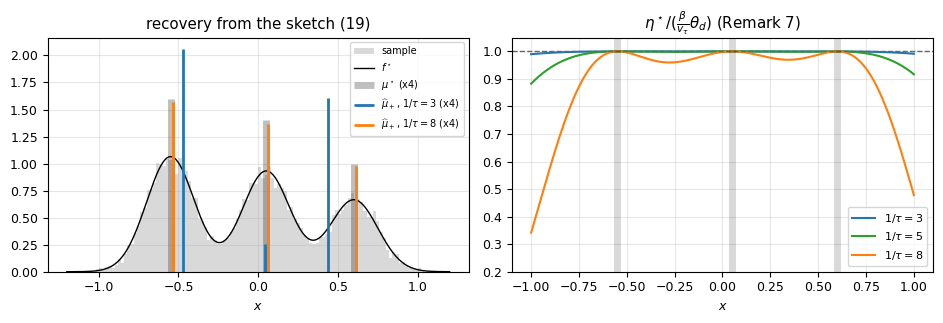

In [22]:
tg = np.linspace(-1, 1, 2001)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.3))
hx = np.linspace(-1.2, 1.2, 400)
ax[0].hist(X6, bins=120, range=(-1.2, 1.2), density=True, color="0.85", label="sample")
ax[0].plot(hx, sum(a * np.exp(-(hx - t) ** 2 / (2 * SIG6 ** 2)) / np.sqrt(2 * np.pi * SIG6 ** 2) for a, t in zip(A6, T6)), "k", lw=1, label="$f^\\star$")
ax[0].vlines(T6, 0, A6 * 4, colors="k", lw=5, alpha=0.25, label="$\\mu^\\star$ (x4)")
for i, inv_tau in enumerate((3.0, 8.0)):
    o = res6[(inv_tau, 0)]
    ax[0].vlines(o["atoms"] + 0.012 * (2 * i - 1), 0, o["weights"] * 4, colors=f"C{i}", lw=2, label=f"$\\widehat\\mu_+$, $1/\\tau={inv_tau:.0f}$ (x4)")
ax[0].set_xlabel("$x$"); ax[0].legend(fontsize=7); ax[0].set_title("recovery from the sketch (19)")

for i, inv_tau in enumerate((3.0, 5.0, 8.0)):
    o = res6[(inv_tau, 0)]
    Yp, Ym = o["yp"].y.value, o["ym"].y.value
    u = o["zhat"] - o["Aop"] @ (Yp - Ym)
    Er = np.array([sum((1j * x * tg) ** j / math.factorial(j) for j in range(o["r"] + 1)) for x in o["xi"]])
    eta_t = np.real((np.conj(u) * o["Ghat"]) @ Er) / M6 * peval(o["th"], tg[:, None])    # eta* on the grid
    ax[1].plot(tg, eta_t / (PEN * peval(o["th"], tg[:, None])), color=["C0", "C2", "C1"][i], label=f"$1/\\tau={inv_tau:.0f}$")
    # coefficients of eta* and the SoS identity  PEN*theta_d - eta* = sigma_0 + (1 - x^2) sigma_1
    eta_c = np.real((np.conj(u) * o["Ghat"]) @ (o["Aop"] / o["Ghat"][:, None])) / M6
    Z0, Z1 = o["cons"][0].dual_value, o["cons"][2].dual_value
    D = o["D"]
    v0 = lambda t: np.array([t ** k for k in range(D + 1)]); v1 = lambda t: np.array([t ** k for k in range(D)])
    lhs = PEN * peval(o["th"], tg[:, None]) - np.polynomial.polynomial.polyval(tg, eta_c)
    rhs = np.array([v0(t) @ Z0 @ v0(t) + (1 - t ** 2) * (v1(t) @ Z1 @ v1(t)) for t in tg])
    j = np.argmax(eta_t / peval(o["th"], tg[:, None]))
    print(f"band {inv_tau:.0f}: max |(beta/v_tau) theta_d - eta* - sigma_0 - (1-x^2) sigma_1| on X = {np.abs(lhs - rhs).max():.1e} "
          f"(scale {PEN * np.abs(peval(o['th'], tg[:, None])).max():.1e});  max normalised certificate "
          f"{(eta_t / (PEN * peval(o['th'], tg[:, None]))).max():.6f}, min {(eta_t / (PEN * peval(o['th'], tg[:, None]))).min():.3f}; "
          f"value at the atoms {np.round(np.interp(o['atoms'], tg, eta_t / (PEN * peval(o['th'], tg[:, None]))), 6)}")
ax[1].axhline(1, color="0.4", ls="--", lw=1); ax[1].set_ylim(0.2, 1.05)
ax[1].vlines(T6, 0.2, 1.05, colors="k", lw=5, alpha=0.15)
ax[1].set_xlabel("$x$"); ax[1].legend(); ax[1].set_title("$\\eta^\\star/(\\frac{\\beta}{v_\\tau}\\theta_d)$ (Remark 7)")
plt.tight_layout(); plt.show()

**Kernel-discrepancy form (Proposition 23, Section 6.7).** The data term of (17c) equals
$\frac12\|\mathsf P_n-G_\Sigma\star\mu\|^2_{k_m}$ with $k_m(x,x')=\frac{v_\tau}m\sum_\ell e^{i\xi_\ell(x-x')}$, and
$\mathbb E_\Lambda k_m(x,x')=\sin((x-x')/\tau)/(\pi(x-x'))$. We check the first identity for $\mu=\widehat\mu_+$ by computing the
double integral with a quadrature of $G_\Sigma\star\mu$, and the second by averaging $k_m$ over $2000$ frequency draws.

In [23]:
o = res6[(8.0, 0)]; inv_tau = o["inv_tau"]; vtau = inv_tau / np.pi; xi = o["xi"]
muA, muW = o["atoms"], o["weights"]
data_term = vtau / (2 * M6) * np.sum(np.abs(o["zhat"] - o["Ghat"] * (np.exp(1j * np.outer(xi, muA)) @ muW)) ** 2)
xq = np.linspace(-3, 3, 6001); dxq = xq[1] - xq[0]
dens = sum(w * np.exp(-(xq - t) ** 2 / (2 * SIG6 ** 2)) / np.sqrt(2 * np.pi * SIG6 ** 2) for w, t in zip(muW, muA))
F_rho = np.exp(1j * np.outer(xi, X6)).mean(1) - (np.exp(1j * np.outer(xi, xq)) * dxq) @ dens    # F(P_n - G*mu)(xi_l)
mmd2 = vtau / M6 * np.sum(np.abs(F_rho) ** 2)                                                    # ||.||_{k_m}^2
print(f"data term of (17c) = {data_term:.8e},  (1/2)||P_n - G*mu||^2_km by quadrature = {mmd2 / 2:.8e}")
u = np.array([0.05, 0.3, 1.0])
xi_mc = np.random.default_rng(SEED + 2).uniform(-inv_tau, inv_tau, 10 ** 6)       # E_Lambda k_m = E v_tau e^{i xi u}
km = vtau * np.cos(np.outer(xi_mc, u)).mean(0)
print(f"E k_m(u) at u = {u}: Monte Carlo over 1e6 frequencies {np.round(km, 4)} (standard error about {vtau / np.sqrt(2e6):.0e}),"
      f" sin(u/tau)/(pi u) = {np.round(np.sin(u * inv_tau) / (np.pi * u), 4)}")

data term of (17c) = 1.54231476e-04,  (1/2)||P_n - G*mu||^2_km by quadrature = 1.54231476e-04
E k_m(u) at u = [0.05 0.3  1.  ]: Monte Carlo over 1e6 frequencies [2.4791 0.7173 0.3141] (standard error about 2e-03), sin(u/tau)/(pi u) = [2.4791 0.7167 0.3149]


# Part II. Reproduction of the figures

| Paper figure | File in `figs/` | Section | Generated by |
|---|---|---|---|
| Figure 1 | `fig_global_opt.pdf` | 5.6, global minimisation benchmark | `code/bench_global_opt.ipynb` |
| Figure 2 (a) | `fig_blasso_2dgmm_a.pdf` | 6.5, band $1/\tau=1$ | `code/fig_blasso_2dgmm.ipynb` |
| Figure 2 (b) | `fig_blasso_2dgmm_b.pdf` | 6.5, band $1/\tau=6$ | `code/fig_blasso_2dgmm.ipynb` |
| Figure 2 (c) | `fig_blasso_2dgmm_c.pdf` | 6.5, singular values, base / H1 / H2 | `code/fig_blasso_2dgmm.ipynb` |
| Figure 3 | `fig_blasso_2dgmm_certif.pdf` | 6.5, dual certificates $\eta$, $s_A$ | `code/fig_blasso_2dgmm.ipynb` |
| Figure 4 (a) | `fig_deconv_2d_a.pdf` | 6.6, noisy image, 40 dB | `code/fig_deconv_2d.ipynb` |
| Figure 4 (b) | `fig_deconv_2d_b.pdf` | 6.6, true vs recovered signed spikes | `code/fig_deconv_2d.ipynb` |
| Figure 4 (c) | `fig_deconv_2d_c.pdf` | 6.6, singular values of $M_D(y_\pm)$ | `code/fig_deconv_2d.ipynb` |
| Figure 5 | `fig_deconv_2d_cert.pdf` | 6.6, dual certificate at 40 dB | `code/fig_deconv_2d.ipynb` |
| Figure 6 | `fig_deconv_2d_h1.pdf` | 6.6, H1 correction at 30 dB (Remark 14) | `code/fig_deconv_2d.ipynb` |

Figures in `figs/extra/` (not in the paper) are listed by the cell below with the notebook that names them. The
benchmark notebooks `code/bench_global_opt.ipynb`, `code/bench_comparison.ipynb` and `code/robustness_sec6.ipynb` are
included when they exist. With `RUN_FULL = False` (default) nothing is executed: the cells check the figure files and
print the outputs stored in the notebooks. With `RUN_FULL = True` the notebooks are executed with `nbclient` (kernel
`kme-sos`) on copies in a temporary directory whose layout mirrors the project, so their figures land in the temporary
`figs/`; they are copied to the project `figs/` only if `WRITE_FIGS = True`. On the machine used (under load from other jobs),
the two figure notebooks took about 10 s and 5 min; the benchmark notebooks add their own running time.

In [24]:
RUN_FULL = False       # True: re-execute the notebooks below on temporary copies
WRITE_FIGS = False     # True (with RUN_FULL): copy the regenerated figures into the project figs/

HERE = os.path.abspath(".")
ROOT = os.path.dirname(HERE) if os.path.basename(HERE) == "code" else HERE
CODE, FIGS = os.path.join(ROOT, "code"), os.path.join(ROOT, "figs")
PAPER_FIGS = {
    "fig_blasso_2dgmm.ipynb": ["fig_blasso_2dgmm_a.pdf", "fig_blasso_2dgmm_b.pdf", "fig_blasso_2dgmm_c.pdf",
                               "fig_blasso_2dgmm_certif.pdf"],
    "fig_deconv_2d.ipynb": ["fig_deconv_2d_a.pdf", "fig_deconv_2d_b.pdf", "fig_deconv_2d_c.pdf",
                            "fig_deconv_2d_cert.pdf", "fig_deconv_2d_h1.pdf"],
}
OPTIONAL_NBS = ["bench_global_opt.ipynb", "bench_comparison.ipynb", "robustness_sec6.ipynb"]
NOTEBOOKS = list(PAPER_FIGS) + [nb for nb in OPTIONAL_NBS if os.path.exists(os.path.join(CODE, nb))]
print("project root:", ROOT)
print("notebooks found:", NOTEBOOKS, "| optional notebooks absent:", [nb for nb in OPTIONAL_NBS if nb not in NOTEBOOKS])

def fmt_time(p):
    return time.strftime("%Y-%m-%d %H:%M", time.localtime(os.path.getmtime(p)))

missing = []
for nb, files in PAPER_FIGS.items():
    nbp = os.path.join(CODE, nb)
    print(f"\n{nb}  (notebook modified {fmt_time(nbp) if os.path.exists(nbp) else 'MISSING'})")
    for fn in files:
        p = os.path.join(FIGS, fn)
        if os.path.exists(p):
            print(f"  {fn:32s} {os.path.getsize(p) / 1024:7.1f} kB   {fmt_time(p)}")
        else:
            print(f"  {fn:32s} MISSING"); missing.append(fn)
extra = sorted(glob.glob(os.path.join(FIGS, "extra", "*")))
print(f"\nfigs/extra: {len(extra)} file(s)")
nb_src = {}
for nb in NOTEBOOKS:
    with open(os.path.join(CODE, nb)) as fh:
        nb_src[nb] = "\n".join("".join(c["source"]) for c in json.load(fh)["cells"])
for p in extra:
    stem = os.path.splitext(os.path.basename(p))[0]
    prefix = stem.split("_")[0]
    owners = [nb for nb, s in nb_src.items() if stem in s] or [nb for nb, s in nb_src.items() if f"{prefix}_" in s]
    print(f"  {os.path.basename(p):40s} {os.path.getsize(p) / 1024:7.1f} kB   {fmt_time(p)}   named in: {owners or 'no notebook found'}")
print("\nall paper figures present:", not missing)

project root: .
notebooks found: ['fig_blasso_2dgmm.ipynb', 'fig_deconv_2d.ipynb', 'bench_global_opt.ipynb', 'bench_comparison.ipynb', 'robustness_sec6.ipynb'] | optional notebooks absent: []

fig_blasso_2dgmm.ipynb  (notebook modified 2026-09-29 09:11)
  fig_blasso_2dgmm_a.pdf              28.4 kB   2026-09-29 08:10
  fig_blasso_2dgmm_b.pdf              28.5 kB   2026-09-29 08:10
  fig_blasso_2dgmm_c.pdf              17.1 kB   2026-09-29 08:10
  fig_blasso_2dgmm_certif.pdf        506.3 kB   2026-09-29 08:10

fig_deconv_2d.ipynb  (notebook modified 2026-09-29 08:10)
  fig_deconv_2d_a.pdf                 10.0 kB   2026-09-29 08:10
  fig_deconv_2d_b.pdf                  7.5 kB   2026-09-29 08:10
  fig_deconv_2d_c.pdf                 14.6 kB   2026-09-29 08:10
  fig_deconv_2d_cert.pdf             262.7 kB   2026-09-29 08:10
  fig_deconv_2d_h1.pdf                15.6 kB   2026-09-29 08:10

figs/extra: 19 file(s)
  g1_ball.pdf                                 24.3 kB   2026-09-28 23:31   nam

In [25]:
def stored_outputs(path, max_lines=400):
    # stdout of every code cell, in order, with the cell index; warnings (stderr) are counted, not printed
    with open(path) as fh:
        nb = json.load(fh)
    code_cells = [c for c in nb["cells"] if c["cell_type"] == "code"]
    unexecuted = sum(c.get("execution_count") is None for c in code_cells)
    n_err, n_warn, lines = 0, 0, []
    for i, c in enumerate(nb["cells"]):
        if c["cell_type"] != "code":
            continue
        for o in c.get("outputs", []):
            if o["output_type"] == "stream" and o.get("name") == "stdout":
                lines += [f"[cell {i:2d}] {l}" for l in "".join(o["text"]).splitlines() if l.strip()]
            elif o["output_type"] == "stream":
                n_warn += "".join(o["text"]).count("Warning")
            elif o["output_type"] == "error":
                n_err += 1; lines.append(f"[cell {i:2d}] ERROR {o['ename']}: {o['evalue'][:200]}")
    kern = nb["metadata"].get("kernelspec", {}).get("name", "?")
    print(f"{os.path.basename(path)}: {len(code_cells)} code cells, {unexecuted} without stored execution, "
          f"{n_err} error output(s), {n_warn} warning(s) on stderr, kernelspec '{kern}'")
    for l in lines[:max_lines]:
        print("   " + l[:220])
    if len(lines) > max_lines:
        print(f"   ... {len(lines) - max_lines} more lines")

for nb in NOTEBOOKS:
    print("=" * 100)
    stored_outputs(os.path.join(CODE, nb), max_lines=400 if nb in PAPER_FIGS else 150)

fig_blasso_2dgmm.ipynb: 18 code cells, 0 without stored execution, 0 error output(s), 2 warning(s) on stderr, kernelspec 'python3'
   [cell  1] python 3.13.3 | numpy 2.3.3 | matplotlib 3.10.6 | cvxpy 1.9.1 | clarabel 0.11.1 | scs 3.2.11
   [cell  3] 3 atoms; D=6 -> moment matrix 28x28; fit moments up to degree 4
   [cell  5] sample: (20000, 2)
   [cell  9] raw deconv (exact): max err = 4.342012860369948e-15
   [cell  9] CF band deconv (exact): max err on deg<=4 = 1.05e-02
   [cell 14] extraction from exact moments: max position error = 6.3e-16, max weight error = 6.7e-16
   [cell 16]   solve [smooth, base]: CLARABEL status=optimal_inaccurate
   [cell 16] [smooth] base: 3 atoms | moment-fit RMS=1.09e-04 | rank-surrogate L(beta=1e-3)=8.01
   [cell 16]   solve [smooth, H1 re-solve 1]: CLARABEL status=optimal_inaccurate
   [cell 16] [smooth] H1 re-solve 1: 3 atoms, accepted
   [cell 16]   solve [smooth, H1 re-solve 2]: CLARABEL status=optimal_inaccurate
   [cell 16] [smooth] H1 re-solve 2:

In [26]:
# Numbers quoted in the paper against the outputs stored in the two figure notebooks. The patterns are matched
# on the printed lines, so a change of print format shows up as "not found" rather than as a wrong value.
import re
def stdout_lines(path):
    with open(path) as fh:
        nb = json.load(fh)
    return [l for c in nb["cells"] if c["cell_type"] == "code" for o in c.get("outputs", [])
            if o["output_type"] == "stream" and o.get("name") == "stdout" for l in "".join(o["text"]).splitlines()]

def find(lines, pat):
    for l in lines:
        m = re.search(pat, l)
        if m:
            return m.groups()
    return None

def block(lines, header):
    out, on = [], False
    for l in lines:
        if l.strip().startswith("---"):
            on = header in l
            continue
        if on:
            out.append(l)
    return out

def errs(lines, a="dpos", b="dw"):
    return [(float(x), float(y)) for l in lines for x, y in re.findall(a + r"=([0-9.eE+-]+)\s+" + b + r"=([0-9.eE+-]+)", l)]

def show(rows):
    for what, paper, stored in rows:
        print(f"  {what:58s} paper: {paper:26s} stored: {stored if stored is not None else 'not found'}")

L = stdout_lines(os.path.join(CODE, "fig_blasso_2dgmm.ipynb"))
rows = []
m = find(L, r"CF band deconv \(exact\).*=\s*([0-9.eE+-]+)"); rows.append(("band-1 moment error on exact data (Section 6.5)", "1e-2", m and m[0]))
m = find(L, r"\[smooth\] H1 rank-surrogate\s*([0-9.]+)\s*->\s*([0-9.]+)")
rows.append(("rank surrogate, base -> H1 (Section 6.5)", "8.01 -> 4.74", m and f"{m[0]} -> {m[1]}"))
m = find(L, r"\[smooth\] H2.*rank-surrogate\s*([0-9.]+)"); rows.append(("rank surrogate, H2", "5.90", m and m[0]))
e = errs(block(L, "smooth, base"))
rows.append(("band 1: max position / weight error", "0.05 / 0.02", e and f"{max(x for x, _ in e):.3f} / {max(y for _, y in e):.3f}"))
m = find(L, r"\[broad\] base:\s*(\d+) atoms"); rows.append(("band 6: number of extracted atoms", "4", m and m[0]))
bb = block(L, "broad, base"); e = errs(bb)
if e:
    pulls = sorted(x for x, _ in e)[:3]
    far = bb[int(np.argmax([x for x, _ in e]))]
    sp = re.search(r"\(([+-][0-9.]+),([+-][0-9.]+)\)", far)
    rows.append(("band 6: pull of the three true atoms", "about 0.13", ", ".join(f"{x:.3f}" for x in pulls)))
    rows.append(("band 6: spurious atom", "(-0.60, 0.59)", sp and f"({sp.group(1)}, {sp.group(2)})"))
m = find(L, r"band 1, H1:.*moves vs base.*\(max ([0-9.]+)\)"); m2 = find(L, r"band 1, H2:.*moves vs base.*\(max ([0-9.]+)\)")
rows.append(("band 1: atoms move under H1 / H2", "not quoted (#60)", m and m2 and f"{m[0]} / {m2[0]}"))
m = find(L, r"segment x_1=0.7, x_2 in .*1-min = ([0-9.eE+-]+)")
rows.append(("band 1: 1 - min eta on the segment x_1 = 0.7", "2.7e-3", m and m[0]))
print("fig_blasso_2dgmm.ipynb"); show(rows)

L = stdout_lines(os.path.join(CODE, "fig_deconv_2d.ipynb"))
rows = []
m = find(L, r"^y\+: rank (\d+), svals\[:4\]=\[([^\]]+)\]")
if m:
    sv = [float(v) for v in m[1].split()]; rows.append(("40 dB: rank of y_+, gap after sv_2", "2, 27", f"{m[0]}, {sv[1] / sv[2]:.1f}"))
m = find(L, r"^y-: rank (\d+), svals\[:4\]=\[([^\]]+)\]")
if m:
    sv = [float(v) for v in m[1].split()]; rows.append(("40 dB: rank of y_-, gap after sv_1", "1, 39", f"{m[0]}, {sv[0] / sv[1]:.1f}"))
e = errs([l for l in L if "-> " in l and "rec" in l], "dpos", "da")
rows.append(("40 dB: max position / amplitude error", "2e-3 / 1e-3", e and f"{max(x for x, _ in e):.1e} / {max(y for _, y in e):.1e}"))
m = find(L, r"max\|eta\| on the 161\^2 grid = ([0-9.]+)") or find(L, r"max\|eta\|=\s*([0-9.]+)")
rows.append(("40 dB: max |eta| on the 161^2 grid", "1.00001", m and m[0]))
m = find(L, r"max\|eta\| at distance > 0.15 from every spike = ([0-9.]+) at \(([^)]*)\)")
rows.append(("40 dB: max |eta| away from the spikes", "0.99992 at (1.2, 1.2)", m and f"{m[0]} at ({m[1]})"))
m = find(L, r"30 dB:\s*base rk\(y\+\)=(\d+) rk\(y-\)=(\d+)\s*->\s*H1 rk\(y\+\)=(\d+) rk\(y-\)=(\d+)")
rows.append(("30 dB: ranks, base -> H1 (Remark 14)", "4, 3 -> 2, 1", m and f"{m[0]}, {m[1]} -> {m[2]}, {m[3]}"))
e = errs([l for l in L if "atom (" in l], "dpos", "da")
rows.append(("30 dB, H1: max position / amplitude error", "1e-2 / 2e-2", e and f"{max(x for x, _ in e):.1e} / {max(y for _, y in e):.1e}"))
m = find(L, r"success per SNR \(sweep \+ main.*?(\{.*\})")
if m:
    rows.append(("successes, sweep + main 40 dB + 30 dB base (Remark 13)", "40:6/7 37:2/3 35:1/5 32,30:0/7", m[0]))
else:
    m = find(L, r"success rate per SNR.*?(\{.*\})")
    rows.append(("SNR sweep successes only (Remark 13 adds two draws)", "40:6/7 37:2/3 35:1/5 32,30:0/7", m and m[0]))
print("fig_deconv_2d.ipynb"); show(rows)

fig_blasso_2dgmm.ipynb
  band-1 moment error on exact data (Section 6.5)            paper: 1e-2                       stored: 1.05e-02
  rank surrogate, base -> H1 (Section 6.5)                   paper: 8.01 -> 4.74               stored: 8.01 -> 4.74
  rank surrogate, H2                                         paper: 5.90                       stored: 5.90
  band 1: max position / weight error                        paper: 0.05 / 0.02                stored: 0.048 / 0.017
  band 6: number of extracted atoms                          paper: 4                          stored: 4
  band 6: pull of the three true atoms                       paper: about 0.13                 stored: 0.133, 0.134, 0.140
  band 6: spurious atom                                      paper: (-0.60, 0.59)              stored: (-0.599, +0.587)
  band 1: atoms move under H1 / H2                           paper: not quoted (#60)           stored: 0.0039 / 0.0043
  band 1: 1 - min eta on the segment x_1 = 0.7           

In [27]:
if RUN_FULL:
    import nbformat
    from nbclient import NotebookClient
    tmp = tempfile.mkdtemp(prefix="kme_sos_run_")
    os.makedirs(os.path.join(tmp, "code")); os.makedirs(os.path.join(tmp, "figs", "extra"))
    for fn in os.listdir(CODE):                      # data or helper files the notebooks may read
        if not fn.endswith(".ipynb") and os.path.isfile(os.path.join(CODE, fn)):
            shutil.copy(os.path.join(CODE, fn), os.path.join(tmp, "code", fn))
    print("temporary project:", tmp)
    for nb in NOTEBOOKS:
        src, dst = os.path.join(CODE, nb), os.path.join(tmp, "code", nb)
        shutil.copy(src, dst)
        book = nbformat.read(dst, as_version=4)
        t0 = time.time()
        try:
            NotebookClient(book, timeout=7200, kernel_name="kme-sos",
                           resources={"metadata": {"path": os.path.join(tmp, "code")}}).execute()
            status = "ok"
        except Exception as e:                       # reported, and the partial notebook is kept
            status = f"FAILED: {type(e).__name__}: {str(e)[:300]}"
        nbformat.write(book, dst)
        print(f"\n{nb}: {status}, {time.time() - t0:.0f} s")
        stored_outputs(dst)
        strip = lambda L: [re.sub(r"\(\d+s\)", "", l) for l in L if "saved" not in l]
        print("  printed output identical to the stored one (timings and file paths aside):",
              strip(stdout_lines(src)) == strip(stdout_lines(dst)))
    def pdf_body(p):
        with open(p, "rb") as fh:
            return re.sub(rb"/CreationDate \([^)]*\)|/ModDate \([^)]*\)|/ID \[[^\]]*\]", b"", fh.read())
    new = sorted(glob.glob(os.path.join(tmp, "figs", "**", "*.*"), recursive=True))
    print("\nfigures written in the temporary figs/:")
    for p in new:
        rel = os.path.relpath(p, os.path.join(tmp, "figs")); q = os.path.join(FIGS, rel)
        cmpres = ("new file" if not os.path.exists(q) else
                  "identical to figs/ up to the PDF dates" if pdf_body(p) == pdf_body(q) else "differs from figs/")
        print(f"  {rel:36s} {cmpres}")
    if WRITE_FIGS:
        for p in new:
            rel = os.path.relpath(p, os.path.join(tmp, "figs"))
            os.makedirs(os.path.dirname(os.path.join(FIGS, rel)), exist_ok=True)
            shutil.copy(p, os.path.join(FIGS, rel))
        print(f"copied {len(new)} file(s) into {FIGS}")
    else:
        print("WRITE_FIGS = False: project figs/ left unchanged")
else:
    print("RUN_FULL = False: no notebook executed")

RUN_FULL = False: no notebook executed


In [28]:
print(f"total runtime of this notebook: {time.time() - T_START:.1f} s")
print(f"conic solves: {len(SOLVER_LOG)};", status_summary(""))
bad = [r for r in SOLVER_LOG if r[2] not in ("optimal", "optimal_inaccurate")]
print("attempts not returning a solution:", bad if bad else "none")

total runtime of this notebook: 5.4 s
conic solves: 79; 48 x CLARABEL optimal, 29 x CLARABEL optimal_inaccurate, 1 x CLARABEL SolverError, 1 x SCS infeasible
attempts not returning a solution: [('s4c H1 eps=0.2 it=0', 'CLARABEL', 'SolverError'), ('s4c H1 eps=0.2 it=0', 'SCS', 'infeasible')]
